[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter15_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 15: LLMs and Sentiment Analysis

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces the charts and numbers of Lecture 15 for the topics below (the Lopez-Lira & Tang case-study figures and the AI-for-discovery section are not included):
- labelled financial texts: Financial PhraseBank (Malo et al., 2014) and Twitter Financial News (2022);
- dictionaries (Harvard IV-4, Loughran–McDonald), VADER, FinBERT, zero-shot LLMs (Qwen2.5, 0.5B–14B), embeddings;
- a look-ahead test: does an LLM already know what markets did?
- sentiment scores as estimates: attenuation, instruments, prediction-powered inference, calibration, few clusters, specification curves;
- FNSPID headlines about 16 large US stocks and the daily prices of the course: from sentiment to a trading signal.

The language-model scores are saved with the chapter; set `RECOMPUTE = True` to recompute them (hours without a GPU).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_15'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/2026 MFM/MFM/notebooks/EN


In [2]:
import os
import io
import re
import sys
import json
import time
import zipfile
import subprocess
import urllib.request
for pkg, mod in (('pysentiment2', 'pysentiment2'), ('transformers', 'transformers')):
    try:
        __import__(mod)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')

PHRASEBANK_URL = ('https://huggingface.co/datasets/takala/financial_phrasebank/resolve/main/data/'
                  'FinancialPhraseBank-v1.0.zip')
TWITTER_URL = 'https://huggingface.co/datasets/zeroshot/twitter-financial-news-sentiment/resolve/main/'
FNSPID_URLS = ['https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_news/All_external.csv',
               'https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_news/nasdaq_exteral_data.csv']
LABELS = ['negative', 'neutral', 'positive']
TW_MAP = {0: 'negative', 1: 'positive', 2: 'neutral'}          # Bearish, Bullish, Neutral
AGREE = ['50Agree', '66Agree', '75Agree', 'AllAgree']

# US stocks with FNSPID news and daily prices in the course data (Meta appears in FNSPID as FB until 2022)
TICKERS = {'AAPL': 'AAPL.US', 'MSFT': 'MSFT.US', 'AMZN': 'AMZN.US', 'NVDA': 'NVDA.US', 'TSLA': 'TSLA.US',
           'GOOGL': 'GOOGL.US', 'GOOG': 'GOOGL.US', 'META': 'META.US', 'FB': 'META.US', 'JPM': 'JPM.US',
           'BAC': 'BAC.US', 'C': 'C.US', 'GS': 'GS.US', 'MS': 'MS.US', 'WFC': 'WFC.US', 'CSCO': 'CSCO.US',
           'GME': 'GME.US', 'MSTR': 'MSTR.US', 'COIN': 'COIN.US'}
LLM_SIZES = {'0.5B': 'Qwen/Qwen2.5-0.5B-Instruct', '1.5B': 'Qwen/Qwen2.5-1.5B-Instruct',
             '3B': 'Qwen/Qwen2.5-3B-Instruct', '7B': 'Qwen/Qwen2.5-7B-Instruct', '14B': 'Qwen/Qwen2.5-14B-Instruct'}
QWEN_RELEASE = '2024-09-19'          # release of the Qwen2.5 weights
PROMPTS = {
    'P1': ('You classify the sentiment of financial news for investors. '
           'Answer with one word: positive, negative or neutral.', 'Headline: {x}\nSentiment:'),
    'P2': ('You are a financial analyst.', 'Is the following news good, bad or neutral for the stock price of the '
                                           'company it mentions? Answer with one word: positive, negative or '
                                           'neutral.\n\n{x}'),
    'P3': ('You are a helpful assistant.', 'Text: "{x}"\nWhat is the sentiment of this text? Reply positive, '
                                           'negative or neutral.'),
}


# =============================================================================
# MARKET DATA
# =============================================================================
def read_market(symbol):
    """Daily prices of one asset from the course data (local copy or the GitHub repository)."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def stock_returns(symbols, start='2009-01-01'):
    """Simple daily close-to-close returns (%) on the adjusted price, for the stocks and SPY.
    Prices are joined on common days, then returns are computed."""
    px = pd.concat({s: read_market(s)['adjusted_close'] for s in symbols}, axis=1).loc[start:]
    return 100 * px.pct_change(fill_method=None)


# =============================================================================
# LABELLED TEXTS
# =============================================================================
def load_phrasebank():
    """Financial PhraseBank v1.0: 4,846 sentences from financial news, labelled by 16 annotators.
    'agree': the highest agreement threshold reached (50%, 66%, 75%, 100%)."""
    z = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(PHRASEBANK_URL).read()))
    sets = {}
    for lvl in AGREE:
        raw = z.read(f'FinancialPhraseBank-v1.0/Sentences_{lvl}.txt').decode('latin-1')
        sets[lvl] = [tuple(l.rsplit('@', 1)) for l in raw.splitlines() if '@' in l]
    lookup = {lvl: set(v) for lvl, v in sets.items()}
    rows = []
    for text, lab in sets['50Agree']:
        agree = max([i for i, lvl in enumerate(AGREE) if (text, lab) in lookup[lvl]] or [0])
        rows.append((text.strip(), lab.strip(), AGREE[agree]))
    d = pd.DataFrame(rows, columns=['text', 'label', 'agree'])
    return d


def load_twitter(split='valid'):
    """Twitter Financial News Sentiment: financial news headlines posted on Twitter, 2022; train / valid."""
    d = pd.read_csv(TWITTER_URL + f'sent_{split}.csv')
    d['label'] = d['label'].map(TW_MAP)
    return d


# =============================================================================
# DICTIONARIES
# =============================================================================
def load_dictionaries():
    """Word lists: Loughran-McDonald (negative, positive, uncertainty) and Harvard IV-4 (Negativ, Positiv).
    Source: the lists distributed with the pysentiment2 package."""
    try:
        import pysentiment2
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pysentiment2'], check=True)
        import pysentiment2
    st = os.path.join(os.path.dirname(pysentiment2.__file__), 'static')
    lm = pd.read_csv(os.path.join(st, 'LM.csv'))
    lm['Word'] = lm['Word'].astype(str).str.upper()
    gi = pd.read_csv(os.path.join(st, 'HIV-4.csv'), dtype=str)
    gi['Entry'] = gi['Entry'].astype(str).str.upper().str.replace(r'#\d+$', '', regex=True)
    return {'LM_neg': set(lm.loc[lm['Negative'] > 0, 'Word']),
            'LM_pos': set(lm.loc[lm['Positive'] > 0, 'Word']),
            'LM_unc': set(lm.loc[lm['Uncertainty'] > 0, 'Word']),
            'GI_neg': set(gi.loc[gi['Negativ'].notna(), 'Entry']),
            'GI_pos': set(gi.loc[gi['Positiv'].notna(), 'Entry'])}


TOKEN = re.compile(r"[A-Za-z][A-Za-z'\-]*")


def tokens(text):
    """Upper-case words, without digits and punctuation."""
    return [w.upper().strip("'-") for w in TOKEN.findall(str(text))]


def dict_counts(texts, pos, neg):
    """Number of positive and negative words in each text."""
    P = np.array([sum(w in pos for w in tokens(t)) for t in texts])
    N = np.array([sum(w in neg for w in tokens(t)) for t in texts])
    return P, N


def dict_tone(texts, pos, neg):
    """Tone: (P - N) / (P + N); 0 if the text has no dictionary words."""
    P, N = dict_counts(texts, pos, neg)
    return np.where(P + N > 0, (P - N) / np.maximum(P + N, 1), 0.0)


def tone_label(tone, band=0.0):
    return np.where(tone > band, 'positive', np.where(tone < -band, 'negative', 'neutral'))


def vader_compound(texts):
    """VADER compound score (Hutto & Gilbert, 2014), in [-1, 1]."""
    import nltk
    try:
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sia = SentimentIntensityAnalyzer()
    except LookupError:
        nltk.download('vader_lexicon', quiet=True)
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sia = SentimentIntensityAnalyzer()
    return np.array([sia.polarity_scores(str(t))['compound'] for t in texts])


# =============================================================================
# LANGUAGE MODELS
# =============================================================================
def device():
    import torch
    if torch.cuda.is_available():
        return 'cuda'
    if torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'


def finbert_probs(texts, batch=64, name='ProsusAI/finbert'):
    """FinBERT probabilities (negative, neutral, positive) for each text."""
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    tok = AutoTokenizer.from_pretrained(name)
    m = AutoModelForSequenceClassification.from_pretrained(name).to(device()).eval()
    order = [m.config.label2id[l] for l in LABELS]
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), batch):
            b = tok([str(t) for t in texts[i:i + batch]], padding=True, truncation=True, max_length=96,
                    return_tensors='pt').to(m.device)
            out.append(m(**b).logits.float().softmax(-1)[:, order].cpu().numpy())
    return np.vstack(out)


def llm_load(size):
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM
    name = LLM_SIZES[size]
    tok = AutoTokenizer.from_pretrained(name)
    tok.padding_side = 'left'
    dev = device()
    dt = torch.float16 if dev != 'cpu' else torch.float32
    m = AutoModelForCausalLM.from_pretrained(name, dtype=dt).to(dev).eval()
    return tok, m


def llm_choice_probs(tok, m, system, user_texts, choices, batch=16):
    """Zero-shot: relative probabilities of the answer words (first token of each) at the first generation
    step, after the model's chat template."""
    import torch
    ids = [tok.encode(w, add_special_tokens=False)[0] for w in choices]
    prompts = [tok.apply_chat_template([{'role': 'system', 'content': system}, {'role': 'user', 'content': u}],
                                       tokenize=False, add_generation_prompt=True) for u in user_texts]
    out = []
    with torch.no_grad():
        for i in range(0, len(prompts), batch):
            b = tok(prompts[i:i + batch], return_tensors='pt', padding=True).to(m.device)
            lg = m(**b).logits[:, -1, :][:, ids].float()
            out.append(lg.softmax(-1).cpu().numpy())
    return np.vstack(out)


def llm_sentiment(tok, m, texts, prompt='P1', batch=16):
    """Probabilities (negative, neutral, positive) from a zero-shot LLM."""
    system, user = PROMPTS[prompt]
    return llm_choice_probs(tok, m, system, [user.format(x=str(t)) for t in texts], LABELS, batch)


def embed(texts, name='sentence-transformers/all-MiniLM-L6-v2', batch=128):
    """Sentence embeddings: mean of the hidden states (mean pooling), normalised to unit length."""
    import torch
    from transformers import AutoTokenizer, AutoModel
    tok = AutoTokenizer.from_pretrained(name)
    m = AutoModel.from_pretrained(name).to(device()).eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), batch):
            b = tok([str(t) for t in texts[i:i + batch]], padding=True, truncation=True, max_length=96,
                    return_tensors='pt').to(m.device)
            h = m(**b).last_hidden_state
            w = b['attention_mask'].unsqueeze(-1).float()
            e = (h * w).sum(1) / w.sum(1)
            out.append(torch.nn.functional.normalize(e, dim=1).cpu().numpy())
    return np.vstack(out)


def probs_label(P):
    """Label with the highest probability; columns are in the order of LABELS."""
    return np.array(LABELS)[np.asarray(P).argmax(1)]


def net_score(P):
    """Net sentiment score: P(positive) - P(negative), in [-1, 1]."""
    P = np.asarray(P)
    return P[:, 2] - P[:, 0]


# =============================================================================
# CLASSIFICATION METRICS
# =============================================================================
def confusion(y, yhat, labels=LABELS):
    return pd.crosstab(pd.Categorical(y, labels), pd.Categorical(yhat, labels), dropna=False,
                       rownames=['true'], colnames=['predicted'])


def macro_f1(y, yhat, labels=LABELS):
    y, yhat = np.asarray(y), np.asarray(yhat)
    f = []
    for l in labels:
        tp = np.sum((y == l) & (yhat == l))
        p = tp / max(np.sum(yhat == l), 1)
        r = tp / max(np.sum(y == l), 1)
        f.append(0 if p + r == 0 else 2 * p * r / (p + r))
    return float(np.mean(f))


def class_metrics(y, yhat, labels=LABELS):
    """Precision, recall and F1 by class."""
    y, yhat = np.asarray(y), np.asarray(yhat)
    rows = {}
    for l in labels:
        tp = np.sum((y == l) & (yhat == l))
        p = tp / max(np.sum(yhat == l), 1)
        r = tp / max(np.sum(y == l), 1)
        rows[l] = {'precision': p, 'recall': r, 'f1': 0 if p + r == 0 else 2 * p * r / (p + r),
                   'support': int(np.sum(y == l))}
    return pd.DataFrame(rows).T


def boot_ci(y, yhat, stat, B=2000, seed=0, level=0.95):
    """Bootstrap interval (i.i.d. resampling of texts) for a classification statistic."""
    rng = np.random.default_rng(seed)
    y, yhat = np.asarray(y), np.asarray(yhat)
    n = len(y)
    v = [stat(y[i], yhat[i]) for i in (rng.integers(0, n, n) for _ in range(B))]
    return tuple(np.quantile(v, [(1 - level) / 2, (1 + level) / 2]))


def acc(y, yhat):
    return float(np.mean(np.asarray(y) == np.asarray(yhat)))


def mcnemar(y, a, b):
    """Exact McNemar test: compares two classifiers on the same texts.
    n01: A wrong and B right; n10: the reverse."""
    y, a, b = map(np.asarray, (y, a, b))
    ca, cb = a == y, b == y
    n01, n10 = int(np.sum(~ca & cb)), int(np.sum(ca & ~cb))
    p = stats.binomtest(min(n01, n10), n01 + n10, 0.5).pvalue if n01 + n10 > 0 else 1.0
    return n01, n10, float(p)


def diff_ci(y, a, b, B=2000, seed=0):
    """Bootstrap interval for the accuracy difference acc(B) - acc(A), on the same texts."""
    rng = np.random.default_rng(seed)
    y, a, b = map(np.asarray, (y, a, b))
    n = len(y)
    d = [np.mean(b[i] == y[i]) - np.mean(a[i] == y[i]) for i in (rng.integers(0, n, n) for _ in range(B))]
    return tuple(np.quantile(d, [0.025, 0.975]))


# =============================================================================
# DATED NEWS AND SIGNALS
# =============================================================================
def load_fnspid(paths=None, tickers=TICKERS):
    """FNSPID headlines (both parts: external sources and Nasdaq) for the stocks in TICKERS:
    date (UTC), headline, ticker. Repeated headlines (same headline, stock and day) are kept once."""
    out = []
    for src in (paths or FNSPID_URLS):
        for ch in pd.read_csv(src, usecols=['Date', 'Article_title', 'Stock_symbol'], chunksize=500_000, dtype=str,
                              on_bad_lines='skip'):
            out.append(ch[ch['Stock_symbol'].isin(tickers)])
    d = pd.concat(out).dropna()
    d['ts'] = pd.to_datetime(d['Date'], utc=True, errors='coerce')
    d = d.dropna(subset=['ts'])
    d['ticker'] = d['Stock_symbol'].map(lambda s: TICKERS[s].replace('.US', ''))
    d['title'] = d['Article_title'].str.strip()
    d = d.assign(dd=d['ts'].dt.date).drop_duplicates(['ticker', 'title', 'dd'])
    return d[['ts', 'ticker', 'title']].reset_index(drop=True)


def assign_trading_day(ts, days):
    """FNSPID gives only the publication date (the time is 00:00 UTC for almost all headlines): a headline dated d
    is assigned to the first trading day >= d. The time of day is unknown, so the news may appear
    after the close of day d."""
    d0 = ts.dt.tz_convert('UTC').dt.tz_localize(None).dt.normalize()
    days = pd.DatetimeIndex(days).sort_values()
    pos = days.searchsorted(d0.values)
    ok = pos < len(days)
    out = pd.Series(pd.NaT, index=ts.index)
    out[ok] = days[pos[ok]]
    return out


def daily_panel(S, rets):
    """S: mean scores by (day, stock), indexed (day, ticker). Adds the excess return over SPY
    on the news day (r0), on the next two days (r1, r2) and on days -5..+5 (event study:
    rm5..rm1, r0, r1, r2, rp3..rp5). Without a time stamp, r1 may still contain the reaction to the news; the first
    safely tradable return is r2 (from the close of the next day)."""
    ex = rets.drop(columns='SPY').sub(rets['SPY'], axis=0)
    P = S.copy()
    for k in range(-5, 6):
        name = {0: 'r0', 1: 'r1', 2: 'r2'}.get(k, f'rp{k}' if k > 0 else f'rm{-k}')
        sh = ex.shift(-k).stack()
        sh.index.names = ['day', 'ticker']
        P = P.join(sh.rename(name), how='left')
    return P.dropna(subset=['r0', 'r1', 'r2'])


def cluster_ols(y, x, groups):
    """OLS y = a + b x with ordinary and day-clustered standard errors (Petersen, 2009)."""
    X = np.column_stack([np.ones(len(x)), x])
    y = np.asarray(y, float)
    XtX = np.linalg.inv(X.T @ X)
    b = XtX @ X.T @ y
    e = y - X @ b
    n, k = X.shape
    V_ols = XtX * (e @ e) / (n - k)
    idx_g = pd.Series(np.arange(n)).groupby(np.asarray(groups)).apply(list)
    meat = sum(np.outer(X[i].T @ e[i], X[i].T @ e[i]) for i in idx_g)
    G = len(idx_g)
    V_cl = XtX @ meat @ XtX * G / (G - 1) * (n - 1) / (n - k)
    return {'b': b[1], 'a': b[0], 'se_ols': np.sqrt(V_ols[1, 1]), 'se_cl': np.sqrt(V_cl[1, 1]),
            't_ols': b[1] / np.sqrt(V_ols[1, 1]), 't_cl': b[1] / np.sqrt(V_cl[1, 1]),
            'r2': 1 - (e @ e) / np.sum((y - y.mean()) ** 2), 'n': n, 'G': G}


def nw_t(x, lags=None):
    """Mean and t statistic with the Newey-West (HAC) variance."""
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    n = len(x)
    L = lags if lags is not None else int(np.floor(4 * (n / 100) ** (2 / 9)))
    u = x - x.mean()
    v = u @ u / n
    for l in range(1, L + 1):
        v += 2 * (1 - l / (L + 1)) * (u[l:] @ u[:-l]) / n
    return x.mean(), x.mean() / np.sqrt(v / n)


def block_boot_mean(x, B=2000, block=10, seed=0):
    """Moving-block bootstrap interval for the mean of a daily series."""
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float)
    n = len(x)
    nb = int(np.ceil(n / block))
    v = []
    for _ in range(B):
        st = rng.integers(0, n - block + 1, nb)
        v.append(np.concatenate([x[s:s + block] for s in st])[:n].mean())
    return tuple(np.quantile(v, [0.025, 0.975]))


def signal_portfolio(P, col, days, cost_bp=0.0, band=0.0, ret='r2'):
    """Daily strategy: for each stock with news (|score| > band) take the position sign(score), hedged with SPY,
    equal weights; the gain is the excess return in column ret (default r2: the position opens at the
    close of the day after the news, when the news is surely public). Days without positions return 0.
    Cost: cost_bp basis points per trade (stock and SPY, at entry and at exit: 4 x cost)."""
    q = P[P[col].abs() > band]
    lag = {'r0': 0, 'r1': 1, 'r2': 2}[ret]
    pos_day = pd.DatetimeIndex(days)
    idx = pos_day.get_indexer(q.index.get_level_values('day'))
    ok = (idx >= 0) & (idx + lag < len(pos_day))
    q = q[ok]
    earn_day = pos_day[idx[ok] + lag]
    x = pd.Series(np.sign(q[col].values) * q[ret].values, index=earn_day)
    grp = x.groupby(level=0)
    R = pd.DataFrame({'gross': grp.mean(), 'k': grp.size()}).reindex(pos_day).fillna(0.0)
    R['net'] = R['gross'] - np.where(R['k'] > 0, 4 * cost_bp / 100, 0.0)
    return R


def sharpe(x, ppy=252):
    x = np.asarray(x, float)
    return float(np.sqrt(ppy) * x.mean() / x.std(ddof=1))

In [4]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Colours
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Crimson = '#DC3545'
Teal = '#17A2B8'
Magenta = '#D63384'
Brown = '#795548'
Gray = '#7F7F7F'          # reference lines only
LightGray = '#DADADA'     # bands only

LAB_COL = {'negative': IDAred, 'neutral': Amber, 'positive': Forest}
METHODS = ['GI', 'VADER', 'LM', 'TF-IDF + LR', 'MiniLM + LR', 'FinBERT', 'Qwen 0.5B', 'Qwen 1.5B', 'Qwen 3B',
           'Qwen 7B', 'Qwen 14B']
M_COL = {'GI': Brown, 'VADER': Amber, 'LM': Orange, 'TF-IDF + LR': Teal, 'MiniLM + LR': Magenta,
         'FinBERT': MainBlue, 'Qwen 0.5B': '#F4A6A6', 'Qwen 1.5B': '#E86A6A', 'Qwen 3B': Crimson,
         'Qwen 7B': IDAred, 'Qwen 14B': '#7A0000'}
SIZES_B = {'0.5B': 0.5, '1.5B': 1.5, '3B': 3.0, '7B': 7.0, '14B': 14.0}
SCORE_LBL = {'lm': 'Loughran-McDonald tone', 'finbert': 'FinBERT', 'qwen': 'Qwen2.5-7B'}
SCORE_COL = {'lm': Orange, 'finbert': MainBlue, 'qwen': IDAred}
EVENT_COLS = ['rm5', 'rm4', 'rm3', 'rm2', 'rm1', 'r0', 'r1', 'r2', 'rp3', 'rp4', 'rp5']
PERIODS = (('2010', '2015'), ('2016', '2019'), ('2020', '2021'), ('2022', '2023'))


RES = {}
FC_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/Quantlets/Ch_15/'
FC_DIR = next((d for d in ('.', '..', 'Quantlets/Ch_15', '../Quantlets/Ch_15', '../../Quantlets/Ch_15')
               if os.path.exists(os.path.join(d, 'ch15_twitter_scores.csv'))), None)


def save_fig(name):
    """Save the figure as transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def load_csv(name, **kw):
    """A saved score table of the chapter, local copy or the repository."""
    path = os.path.join(FC_DIR, name) if FC_DIR else FC_RAW + name
    return pd.read_csv(path, **kw)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles, labels, ncol=3, y=0.0):
    """One legend for the whole figure, below the panels."""
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def predictions(d):
    """Label predicted by each method (one column per method in the score tables)."""
    v = d['vader'].values
    out = {'GI': tone_label(d['GI_tone'].values), 'LM': tone_label(d['LM_tone'].values),
           'VADER': np.where(v >= 0.05, 'positive', np.where(v <= -0.05, 'negative', 'neutral')),
           'TF-IDF + LR': probs_label(d[[f'tfidf_{l}' for l in LABELS]].values),
           'MiniLM + LR': probs_label(d[[f'emb_{l}' for l in LABELS]].values),
           'FinBERT': probs_label(d[[f'finbert_{l}' for l in LABELS]].values)}
    for s in SIZES_B:
        out[f'Qwen {s}'] = probs_label(d[[f'qwen{s}_{l}' for l in LABELS]].values)
    return out


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items() if not isinstance(v, pd.DataFrame)}
    if isinstance(o, (list, tuple)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    return o

LAB_COL = {'negative': '#CD0000', 'neutral': '#B5853F', 'positive': '#2E7D32'}
METHODS = ['GI', 'VADER', 'LM', 'TF-IDF + LR', 'MiniLM + LR', 'FinBERT', 'Qwen 0.5B', 'Qwen 1.5B', 'Qwen 3B', 'Qwen 7B', 'Qwen 14B']
M_COL = {'GI': '#795548', 'VADER': '#B5853F', 'LM': '#E67E22', 'TF-IDF + LR': '#17A2B8', 'MiniLM + LR': '#D63384', 'FinBERT': '#1A3A6E', 'Qwen 0.5B': '#F4A6A6', 'Qwen 1.5B': '#E86A6A', 'Qwen 3B': '#DC3545', 'Qwen 7B': '#CD0000', 'Qwen 14B': '#7A0000'}
SIZES_B = {'0.5B': 0.5, '1.5B': 1.5, '3B': 3.0, '7B': 7.0, '14B': 14.0}
SCORE_LBL = {'lm': 'Loughran-McDonald tone', 'finbert': 'FinBERT', 'qwen': 'Qwen2.5-7B'}
SCORE_COL = {'lm': '#E67E22', 'finbert': '#1A3A6E', 'qwen': '#CD0000'}
EVENT_COLS = ['rm5', 'rm4', 'rm3', 'rm2', 'rm1', 'r0', 'r1', 'r2', 'rp3', 'rp4', 'rp5']
PERIODS = (('2010', '2015'), ('2016', '2019'), ('2020', '2021'), ('2022', '2023'))


def save_fig(name):
    """Show the figure; with SAVE_TO_DRIVE = True also save it (PDF and PNG) in OUT_DIR."""
    if globals().get('SAVE_TO_DRIVE'):
        for ext in ('pdf', 'png'):
            plt.savefig(os.path.join(OUT_DIR, f'{name}.{ext}'), bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()

In [5]:
HERE = OUT_DIR if globals().get('SAVE_TO_DRIVE') else '.'   # recomputed tables go here
SEED = 15
MONTHS = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


def tick(msg, t0):
    print(f'   {msg}: {time.time() - t0:.0f}s', flush=True)


def dict_cols(d, texts, D):
    for k in ('LM', 'GI'):
        P, N = dict_counts(texts, D[k + '_pos'], D[k + '_neg'])
        d[f'{k}_pos'], d[f'{k}_neg'] = P, N
        d[f'{k}_tone'] = np.where(P + N > 0, (P - N) / np.maximum(P + N, 1), 0.0)
    d['vader'] = vader_compound(texts)


def texts_block():
    t0 = time.time()
    pb, tw, tr = load_phrasebank(), load_twitter('valid'), load_twitter('train')
    D = load_dictionaries()
    out = {'pb': pb[['label', 'agree']].copy(), 'tw': tw[['label']].copy()}
    src = {'pb': pb['text'].tolist(), 'tw': tw['text'].tolist()}
    for k in out:
        dict_cols(out[k], src[k], D)
    tick('dictionaries', t0)
    for k in out:
        P = finbert_probs(src[k])
        for j, l in enumerate(LABELS):
            out[k][f'finbert_{l}'] = P[:, j]
    tick('FinBERT', t0)
    for size in LLM_SIZES:
        tok, m = llm_load(size)
        for k in out:
            prompts = ['P1', 'P2', 'P3'] if (k == 'tw' and size in ('1.5B', '7B', '14B')) else ['P1']
            for pr in prompts:
                t1 = time.time()
                P = llm_sentiment(tok, m, src[k], pr)
                tag = f'qwen{size}' + ('' if pr == 'P1' else f'_{pr}')
                for j, l in enumerate(LABELS):
                    out[k][f'{tag}_{l}'] = P[:, j]
                out[k].attrs[f'time_{tag}'] = (time.time() - t1) / len(src[k])
        del m
        try:
            import torch
            torch.mps.empty_cache()
        except Exception:
            pass
        tick(f'Qwen {size}', t0)
    # embeddings + logistic regression, trained on the Twitter training set
    from sklearn.linear_model import LogisticRegression
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.decomposition import PCA
    Etr, Etw, Epb = embed(tr['text'].tolist()), embed(src['tw']), embed(src['pb'])
    clf = LogisticRegression(C=4.0, max_iter=3000).fit(Etr, tr['label'])
    for k, E in (('tw', Etw), ('pb', Epb)):
        P = clf.predict_proba(E)[:, [list(clf.classes_).index(l) for l in LABELS]]
        for j, l in enumerate(LABELS):
            out[k][f'emb_{l}'] = P[:, j]
    tf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True).fit(tr['text'])
    clf2 = LogisticRegression(C=8.0, max_iter=3000).fit(tf.transform(tr['text']), tr['label'])
    for k in out:
        P = clf2.predict_proba(tf.transform(src[k]))[:, [list(clf2.classes_).index(l) for l in LABELS]]
        for j, l in enumerate(LABELS):
            out[k][f'tfidf_{l}'] = P[:, j]
    pc = PCA(2, random_state=SEED).fit(Etr)
    xy = pc.transform(Etw)
    out['tw']['pc1'], out['tw']['pc2'] = xy[:, 0], xy[:, 1]
    tick('embeddings', t0)
    # learning curve: how many labels are needed?
    rng = np.random.default_rng(SEED)
    rows = []
    for n in (100, 200, 400, 800, 1600, 3200, 6400, len(tr)):
        for rep in range(10 if n < len(tr) else 1):
            idx = rng.choice(len(tr), n, replace=False) if n < len(tr) else np.arange(len(tr))
            y = tr['label'].values[idx]
            if len(set(y)) < 3:
                continue
            a = LogisticRegression(C=4.0, max_iter=3000).fit(Etr[idx], y).predict(Etw)
            tfn = TfidfVectorizer(ngram_range=(1, 2), min_df=1, sublinear_tf=True).fit(tr['text'].values[idx])
            b = LogisticRegression(C=8.0, max_iter=3000).fit(tfn.transform(tr['text'].values[idx]), y).predict(
                tfn.transform(src['tw']))
            rows.append({'n': n, 'rep': rep, 'emb_acc': acc(tw['label'], a), 'emb_f1': macro_f1(tw['label'], a),
                         'tfidf_acc': acc(tw['label'], b), 'tfidf_f1': macro_f1(tw['label'], b)})
    pd.DataFrame(rows).to_csv(os.path.join(HERE, 'ch15_learning_curve.csv'), index=False)
    for k, name in (('pb', 'ch15_phrasebank_scores.csv'), ('tw', 'ch15_twitter_scores.csv')):
        out[k].round(6).to_csv(os.path.join(HERE, name), index_label='id')
    times = {**out['tw'].attrs}
    pd.Series(times).to_csv(os.path.join(HERE, 'ch15_llm_time.csv'), header=['sec_per_text'])
    tick('texts done', t0)


def memory_block(sizes=('1.5B', '7B', '14B')):
    """Monthly direction of the S&P 500 (2000-2026) and daily direction of Apple, asked with no context."""
    t0 = time.time()
    px = read_market('GSPC.INDX')['close']
    mon = px.resample('ME').last()
    mret = 100 * mon.pct_change().dropna().loc['2000-01':'2026-08']
    aapl = read_market('AAPL.US')['adjusted_close']
    dret = 100 * aapl.pct_change().dropna()
    rng = np.random.default_rng(SEED)
    pre = dret.loc['2010-01-01':'2023-12-31']
    post = dret.loc['2024-10-01':]
    days = pd.concat([pre.iloc[np.sort(rng.choice(len(pre), 500, replace=False))], post])
    dm = pd.DataFrame({'ret': mret})
    dd = pd.DataFrame({'ret': days})
    sys_m = 'You are a financial historian. Answer with one word: rise or fall.'
    q_m = [f'Did the S&P 500 index rise or fall during {MONTHS[d.month - 1]} {d.year}?' for d in dm.index]
    sys_d = 'You are a financial historian. Answer with one word: higher or lower.'
    q_d = [f'Did Apple (AAPL) stock close higher or lower on {d.strftime("%A")}, {MONTHS[d.month - 1]} {d.day}, '
           f'{d.year} than on the previous trading day?' for d in dd.index]
    for size in sizes:
        tok, m = llm_load(size)
        dm[f'qwen{size}'] = llm_choice_probs(tok, m, sys_m, q_m, ['rise', 'fall'])[:, 0]
        dd[f'qwen{size}'] = llm_choice_probs(tok, m, sys_d, q_d, ['higher', 'lower'])[:, 0]
        del m
        tick(f'memory {size}', t0)
    dm.round(6).to_csv(os.path.join(HERE, 'ch15_memory_monthly.csv'), index_label='month')
    dd.round(6).to_csv(os.path.join(HERE, 'ch15_memory_daily.csv'), index_label='date')


def news_block(paths=None, llm='7B', batch=64):
    """Scores for each headline, then means by (trading day, stock)."""
    t0 = time.time()
    news = load_fnspid(paths)
    tick(f'FNSPID {len(news)} headlines', t0)
    rets = stock_returns(sorted(set(TICKERS.values())) + ['SPY.US'], start='2009-01-01')
    rets.columns = [c.replace('.US', '') for c in rets.columns]
    news['day'] = assign_trading_day(news['ts'], rets.index)
    news = news.dropna(subset=['day'])
    news = news[news['day'] >= '2009-06-01']
    D = load_dictionaries()
    P, N = dict_counts(news['title'].tolist(), D['LM_pos'], D['LM_neg'])
    news['lm'] = np.where(P + N > 0, (P - N) / np.maximum(P + N, 1), 0.0)
    news['lm_hit'] = (P + N > 0).astype(int)
    F = finbert_probs(news['title'].tolist(), batch=256)
    news['finbert'] = net_score(F)
    news['finbert_lab'] = F.argmax(1) - 1
    tick('FinBERT', t0)
    tok, m = llm_load(llm)
    Q = llm_sentiment(tok, m, news['title'].tolist(), 'P1', batch=batch)
    news['qwen'] = net_score(Q)
    tick(f'Qwen {llm}', t0)
    grp = news.groupby(['day', 'ticker'])
    daily = grp[['finbert', 'lm', 'qwen']].mean()
    daily['n'] = grp.size()
    daily['lm_hit'] = grp['lm_hit'].mean()
    daily.round(6).to_csv(os.path.join(HERE, 'ch15_news_daily.csv'))
    by_year = news.groupby([news['day'].dt.year, 'ticker']).size().unstack(fill_value=0)
    by_year.to_csv(os.path.join(HERE, 'ch15_news_counts.csv'))
    hour = news['ts'].dt.tz_convert('UTC').dt.hour.value_counts().reindex(range(24), fill_value=0)
    exact = ((news['ts'].dt.hour == 0) & (news['ts'].dt.minute == 0) & (news['ts'].dt.second == 0)).mean()
    pd.DataFrame({'n': hour, 'share_midnight': exact}).to_csv(os.path.join(HERE, 'ch15_news_hours.csv'))
    # scores of the individual headlines (without text) for the comparison of methods
    news[['day', 'ticker', 'finbert', 'finbert_lab', 'lm', 'lm_hit', 'qwen']].round(5).to_csv(
        os.path.join(HERE, 'ch15_news_headlines.csv.gz'), index=False, compression='gzip')
    tick('news done', t0)

In [6]:
# True: recompute all scores (downloads FinBERT, MiniLM, Qwen2.5 0.5B-14B and the FNSPID
# headlines; hours without a GPU); False: use the scores saved with Chapter 15.
RECOMPUTE = False
if RECOMPUTE:
    texts_block()
    memory_block()
    news_block()
    FC_DIR = HERE

## 1. Dictionaries: which 'negative' words are not negative in finance?

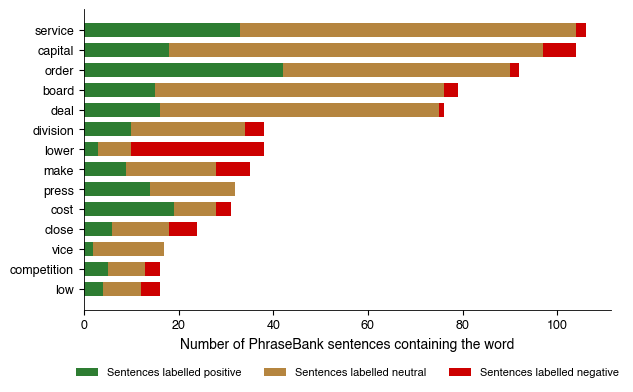

{'n_lm_neg': 2355,
 'n_lm_pos': 354,
 'n_gi_neg': 2007,
 'n_gi_pos': 1637,
 'n_only': 1552,
 'share_gi_neg_not_lm': 0.7732934728450424,
 'sent_gi_neg': 1322,
 'sent_only': 964,
 'sent_only_nonneg': 0.8931535269709544,
 'top': {'SERVICE': 106,
  'CAPITAL': 104,
  'ORDER': 92,
  'BOARD': 79,
  'DEAL': 76,
  'DIVISION': 38,
  'LOWER': 38,
  'MAKE': 35,
  'PRESS': 32,
  'COST': 31,
  'CLOSE': 24,
  'VICE': 17,
  'COMPETITION': 16,
  'LOW': 16},
 'top_nonneg': {'SERVICE': 0.9811320754716981,
  'CAPITAL': 0.9326923076923077,
  'ORDER': 0.9782608695652174,
  'BOARD': 0.9620253164556962,
  'DEAL': 0.9868421052631579,
  'DIVISION': 0.8947368421052632,
  'LOWER': 0.26315789473684215,
  'MAKE': 0.8,
  'PRESS': 1.0,
  'COST': 0.9032258064516129,
  'CLOSE': 0.75,
  'VICE': 1.0,
  'COMPETITION': 0.8125,
  'LOW': 0.75},
 'hit_lm_pb': 0.24411886091621957}

In [7]:
def fig_dict_words(top=14):
    """Words negative in Harvard IV-4 but not in Loughran-McDonald, most frequent in PhraseBank."""
    pb = load_phrasebank()
    D = load_dictionaries()
    only = D['GI_neg'] - D['LM_neg']
    rows = {}
    for t, l in zip(pb['text'], pb['label']):
        for w in set(tokens(t)):
            if w in only:
                r = rows.setdefault(w, {'negative': 0, 'neutral': 0, 'positive': 0})
                r[l] += 1
    f = pd.DataFrame(rows).T
    f['n'] = f.sum(1)
    f = f.sort_values('n', ascending=False).head(top)[::-1]
    fig, ax = plt.subplots(figsize=(6.8, 3.9))
    left = np.zeros(len(f))
    for l in ('positive', 'neutral', 'negative'):
        ax.barh(f.index.str.lower(), f[l], left=left, color=LAB_COL[l], label=f'Sentences labelled {l}', height=0.7)
        left += f[l].values
    ax.set_xlabel('Number of PhraseBank sentences containing the word')
    legend_outside_bottom(ax, ncol=3, y=-0.16)
    save_fig('ch15_dict_words')
    n_gi = sum(1 for t in pb['text'] if any(w in D['GI_neg'] for w in tokens(t)))
    n_only = sum(1 for t in pb['text'] if any(w in only for w in tokens(t)) and
                 not any(w in D['LM_neg'] for w in tokens(t)))
    lab_only = pb['label'][[any(w in only for w in tokens(t)) and not any(w in D['LM_neg'] for w in tokens(t))
                            for t in pb['text']]]
    RES['dict'] = {'n_lm_neg': len(D['LM_neg']), 'n_lm_pos': len(D['LM_pos']), 'n_gi_neg': len(D['GI_neg']),
                   'n_gi_pos': len(D['GI_pos']), 'n_only': len(only),
                   'share_gi_neg_not_lm': len(only) / len(D['GI_neg']),
                   'sent_gi_neg': n_gi, 'sent_only': n_only,
                   'sent_only_nonneg': float((lab_only != 'negative').mean()),
                   'top': {w: int(r['n']) for w, r in f[::-1].iterrows()},
                   'top_nonneg': {w: float(1 - r['negative'] / r['n']) for w, r in f[::-1].iterrows()},
                   'hit_lm_pb': float(np.mean([any(w in D['LM_neg'] | D['LM_pos'] for w in tokens(t))
                                               for t in pb['text']]))}


fig_dict_words()
RES['dict']

In [8]:
# Live: FinBERT and the two dictionaries on five sentences of your choice
mine = ['Operating profit rose to EUR 13.1 mn from EUR 8.7 mn a year earlier.',
        'The company expects higher tax liabilities and rising costs next year.',
        'Shares plunged after the bank cut its dividend.',
        'The board will meet on Tuesday.',
        'Net sales were in line with guidance.']
D = load_dictionaries()
P = finbert_probs(mine)
pd.DataFrame({'text': mine,
              'LM': dict_tone(mine, D['LM_pos'], D['LM_neg']).round(2),
              'GI': dict_tone(mine, D['GI_pos'], D['GI_neg']).round(2),
              'FinBERT': probs_label(P), 'P(pos) - P(neg)': net_score(P).round(3)})

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,text,LM,GI,FinBERT,P(pos) - P(neg)
0,Operating profit rose to EUR 13.1 mn from EUR ...,0.0,1.00,positive,0.926
1,The company expects higher tax liabilities and...,0.0,0.00,negative,-0.240
2,Shares plunged after the bank cut its dividend.,-1.0,-1.00,negative,-0.941
3,The board will meet on Tuesday.,0.0,0.33,neutral,-0.048
4,Net sales were in line with guidance.,0.0,0.00,positive,0.569


In [9]:
# Live (optional, downloads about 1 GB): a small LLM classifies the same five sentences zero-shot
RUN_LLM = False
if RUN_LLM:
    tok, m = llm_load('0.5B')
    Q = llm_sentiment(tok, m, mine)
    print(pd.DataFrame(Q, columns=LABELS, index=mine).round(3))

## 2. Eleven classifiers on two labelled data sets

- Accuracy with a 95% bootstrap interval, macro-F1, confusion matrices, McNemar tests.

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

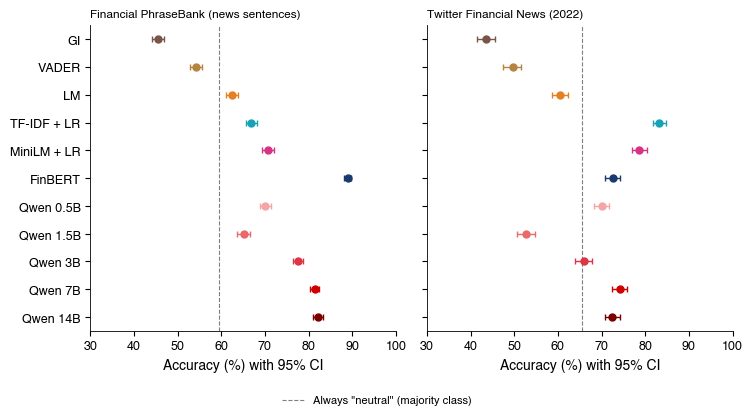

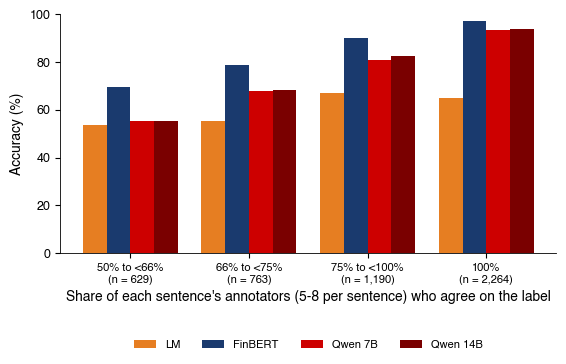

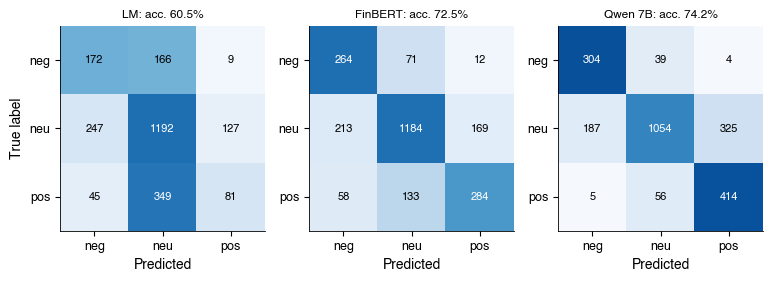

,acc,lo,hi,f1
GI,0.435511,0.415798,0.455622,0.377433
LM,0.605109,0.585427,0.623534,0.462218
VADER,0.496231,0.474037,0.515494,0.447878
TF-IDF + LR,0.832077,0.817839,0.847152,0.760461
MiniLM + LR,0.786432,0.770101,0.803183,0.699287
FinBERT,0.725293,0.706857,0.742462,0.668173
Qwen 0.5B,0.700168,0.682998,0.717755,0.640612
Qwen 1.5B,0.527219,0.507119,0.54732,0.552751
Qwen 3B,0.659966,0.639866,0.67924,0.65455
Qwen 7B,0.742044,0.724026,0.758386,0.725821


In [10]:
def eval_texts():
    pb, tw = load_csv('ch15_phrasebank_scores.csv'), load_csv('ch15_twitter_scores.csv')
    R = {'n_pb': len(pb), 'n_tw': len(tw), 'n_pb_all': int((pb['agree'] == 'AllAgree').sum())}
    for name, d in (('pb', pb), ('tw', tw)):
        y = d['label'].values
        pr = predictions(d)
        R[name] = {}
        for m, yh in pr.items():
            lo, hi = boot_ci(y, yh, acc, B=1000)
            R[name][m] = {'acc': acc(y, yh), 'lo': lo, 'hi': hi, 'f1': macro_f1(y, yh)}
        R[name]['share'] = d['label'].value_counts(normalize=True).to_dict()
        R[name]['always_neutral_f1'] = macro_f1(y, np.full(len(y), 'neutral'))
    # annotator agreement (PhraseBank)
    pr = predictions(pb)
    R['agree'] = {lvl: {m: acc(pb['label'][pb['agree'] == lvl], pr[m][pb['agree'] == lvl])
                        for m in ('LM', 'FinBERT', 'Qwen 7B', 'Qwen 14B')} for lvl in AGREE}
    R['agree_n'] = pb['agree'].value_counts().to_dict()
    # paired tests (Twitter)
    y = tw['label'].values
    pt = predictions(tw)
    R['pairs'] = {}
    for a, b in (('LM', 'FinBERT'), ('FinBERT', 'Qwen 7B'), ('FinBERT', 'Qwen 14B'), ('Qwen 1.5B', 'Qwen 7B'),
                 ('FinBERT', 'MiniLM + LR')):
        n01, n10, p = mcnemar(y, pt[a], pt[b])
        lo, hi = diff_ci(y, pt[a], pt[b], B=1000)
        R['pairs'][f'{a}|{b}'] = {'n01': n01, 'n10': n10, 'p': p, 'diff': acc(y, pt[b]) - acc(y, pt[a]),
                                  'lo': lo, 'hi': hi}
    # prompt wording
    R['prompts'] = {}
    for s in ('1.5B', '7B', '14B'):
        labs = {p: probs_label(tw[[f'qwen{s}{"" if p == "P1" else "_" + p}_{l}' for l in LABELS]].values)
                for p in ('P1', 'P2', 'P3')}
        R['prompts'][s] = {p: {'acc': acc(y, v), 'f1': macro_f1(y, v)} for p, v in labs.items()}
        R['prompts'][s]['agree_all'] = float(np.mean((labs['P1'] == labs['P2']) & (labs['P1'] == labs['P3'])))
        R['prompts'][s]['share_neutral'] = {p: float(np.mean(v == 'neutral')) for p, v in labs.items()}
    t = load_csv('ch15_llm_time.csv', index_col=0)['sec_per_text']
    R['time'] = {k.replace('time_qwen', ''): float(v) for k, v in t.items() if '_' not in k.replace('time_qwen', '')}
    lc = load_csv('ch15_learning_curve.csv')
    R['lc'] = lc.groupby('n')[['emb_acc', 'tfidf_acc', 'emb_f1', 'tfidf_f1']].mean().to_dict('index')
    for name, d in (('pb', pb), ('tw', tw)):
        for m in ('LM', 'FinBERT', 'Qwen 7B'):
            R[name][m]['cm'] = confusion(d['label'], predictions(d)[m]).values.tolist()
    RES['texts'] = R
    return pb, tw


def fig_accuracy():
    R = RES['texts']
    fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.9), sharey=True)
    y = np.arange(len(METHODS))[::-1]
    for ax, key, title in zip(axes, ('pb', 'tw'), ('Financial PhraseBank (news sentences)',
                                                     'Twitter Financial News (2022)')):
        for yi, m in zip(y, METHODS):
            r = R[key][m]
            ax.errorbar(100 * r['acc'], yi, xerr=[[100 * (r['acc'] - r['lo'])], [100 * (r['hi'] - r['acc'])]],
                        fmt='o', color=M_COL[m], ms=5, capsize=2, lw=1)
        base = 100 * R[key]['share']['neutral']
        ax.axvline(base, color=Gray, ls='--', lw=0.8)
        ax.set_title(title, fontsize=8.5, loc='left')
        ax.set_xlabel('Accuracy (%) with 95% CI')
        ax.set_xlim(30, 100)
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(METHODS)
    h = [plt.Line2D([], [], color=Gray, ls='--', lw=0.8)]
    fig_legend_bottom(fig, h, ['Always "neutral" (majority class)'], ncol=1, y=0.0)
    fig.tight_layout()
    save_fig('ch15_accuracy')


def fig_agreement():
    R = RES['texts']['agree']
    fig, ax = plt.subplots(figsize=(6.4, 3.1))
    x = np.arange(len(AGREE))
    for k, (m, c) in enumerate((('LM', Orange), ('FinBERT', MainBlue), ('Qwen 7B', IDAred), ('Qwen 14B', '#7A0000'))):
        ax.bar(x + (k - 1.5) * 0.2, [100 * R[l][m] for l in AGREE], 0.2, color=c, label=m)
    n = RES['texts']['agree_n']
    ax.set_xticks(x)
    rng = {'50Agree': '50% to <66%', '66Agree': '66% to <75%', '75Agree': '75% to <100%', 'AllAgree': '100%'}
    ax.set_xticklabels([f'{rng[l]}\n(n = {n[l]:,})' for l in AGREE], fontsize=8)
    ax.set_xlabel("Share of each sentence's annotators (5-8 per sentence) who agree on the label")
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    legend_outside_bottom(ax, ncol=4, y=-0.32)
    save_fig('ch15_agreement')


def fig_confusion(tw):
    fig, axes = plt.subplots(1, 3, figsize=(7.8, 2.8))
    pr = predictions(tw)
    for ax, m in zip(axes, ('LM', 'FinBERT', 'Qwen 7B')):
        cm = confusion(tw['label'], pr[m]).values
        share = cm / cm.sum(1, keepdims=True)
        ax.imshow(share, cmap='Blues', vmin=0, vmax=1)
        for i in range(3):
            for j in range(3):
                ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', fontsize=8,
                        color='white' if share[i, j] > 0.55 else 'black')
        ax.set_xticks(range(3))
        ax.set_xticklabels(['neg', 'neu', 'pos'])
        ax.set_yticks(range(3))
        ax.set_yticklabels(['neg', 'neu', 'pos'])
        ax.set_title(f'{m}: acc. {100 * acc(tw["label"], pr[m]):.1f}%', fontsize=8.5)
        ax.set_xlabel('Predicted')
    axes[0].set_ylabel('True label')
    fig.tight_layout()
    save_fig('ch15_confusion')


pb, tw = eval_texts()
fig_accuracy()
fig_agreement()
fig_confusion(tw)
pd.DataFrame({k: v for k, v in RES['texts']['tw'].items() if isinstance(v, dict) and 'acc' in v}).T[['acc', 'lo', 'hi', 'f1']].round(3)

In [11]:
pd.DataFrame(RES['texts']['pairs']).T.round(4)

,n01,n10,p,diff,lo,hi
LM|FinBERT,539.0,252.0,0.0000,0.1202,0.0997,0.1415
FinBERT|Qwen 7B,395.0,355.0,0.1544,0.0168,-0.0054,0.0381
FinBERT|Qwen 14B,377.0,380.0,0.9421,-0.0013,-0.0222,0.0222
Qwen 1.5B|Qwen 7B,626.0,113.0,0.0000,0.2148,0.1939,0.2328
FinBERT|MiniLM + LR,400.0,254.0,0.0000,0.0611,0.0402,0.0821


## 3. Large language models: size and prompt wording

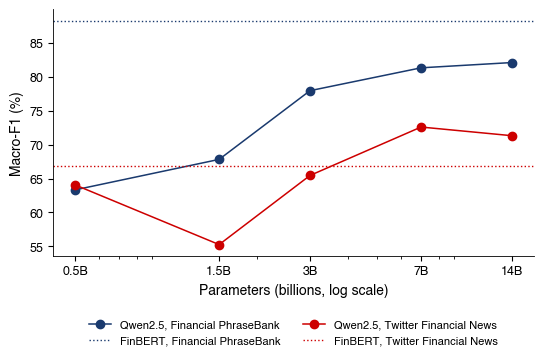

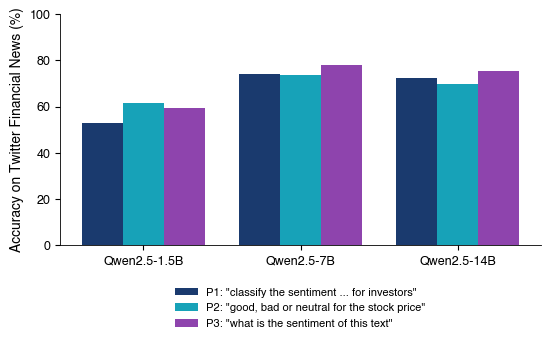

,1.5B,7B,14B
P1,"{'acc': 0.5272194304857621, 'f1': 0.5527505771...","{'acc': 0.7420435510887772, 'f1': 0.7258213002...","{'acc': 0.724036850921273, 'f1': 0.71306875013..."
P2,"{'acc': 0.6168341708542714, 'f1': 0.6265985592...","{'acc': 0.7370184254606366, 'f1': 0.7154270638...","{'acc': 0.6993299832495813, 'f1': 0.6728133024..."
P3,"{'acc': 0.5917085427135679, 'f1': 0.5776169624...","{'acc': 0.7784757118927973, 'f1': 0.7176803844...","{'acc': 0.7558626465661642, 'f1': 0.7328053289..."
agree_all,0.616415,0.671692,0.672948
share_neutral,"{'P1': 0.23241206030150754, 'P2': 0.3421273031...","{'P1': 0.48115577889447236, 'P2': 0.5067001675...","{'P1': 0.4250418760469012, 'P2': 0.51423785594..."


In [12]:
def fig_llm_size():
    R = RES['texts']
    fig, ax = plt.subplots(figsize=(6.2, 3.2))
    xs = list(SIZES_B.values())
    for key, c, lab in (('pb', MainBlue, 'Financial PhraseBank'), ('tw', IDAred, 'Twitter Financial News')):
        ax.plot(xs, [100 * R[key][f'Qwen {s}']['f1'] for s in SIZES_B], 'o-', color=c, label=f'Qwen2.5, {lab}')
        ax.axhline(100 * R[key]['FinBERT']['f1'], color=c, ls=':', lw=1, label=f'FinBERT, {lab}')
    ax.set_xscale('log')
    ax.set_xticks(xs)
    ax.set_xticklabels([f'{s}' for s in SIZES_B])
    ax.set_xlabel('Parameters (billions, log scale)')
    ax.set_ylabel('Macro-F1 (%)')
    legend_outside_bottom(ax, ncol=2, y=-0.22)
    save_fig('ch15_llm_size')


def fig_prompts():
    R = RES['texts']['prompts']
    fig, ax = plt.subplots(figsize=(6.2, 3.0))
    x = np.arange(3)
    for k, (p, c) in enumerate((('P1', MainBlue), ('P2', Teal), ('P3', Purple))):
        ax.bar(x + (k - 1) * 0.26, [100 * R[s][p]['acc'] for s in ('1.5B', '7B', '14B')], 0.26, color=c,
               label={'P1': 'P1: "classify the sentiment ... for investors"',
                      'P2': 'P2: "good, bad or neutral for the stock price"',
                      'P3': 'P3: "what is the sentiment of this text"'}[p])
    ax.set_xticks(x)
    ax.set_xticklabels(['Qwen2.5-1.5B', 'Qwen2.5-7B', 'Qwen2.5-14B'])
    ax.set_ylabel('Accuracy on Twitter Financial News (%)')
    ax.set_ylim(0, 100)
    legend_outside_bottom(ax, ncol=1, y=-0.14)
    save_fig('ch15_prompts')


fig_llm_size()
fig_prompts()
pd.DataFrame(RES['texts']['prompts'])

## 4. Embeddings as features

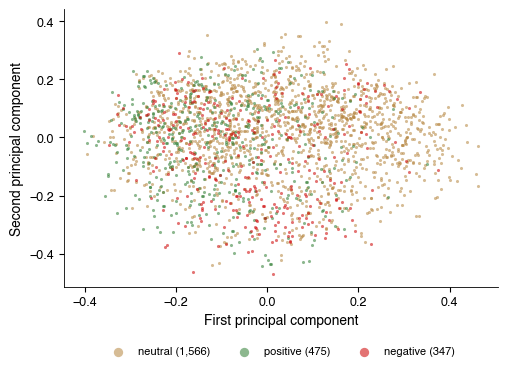

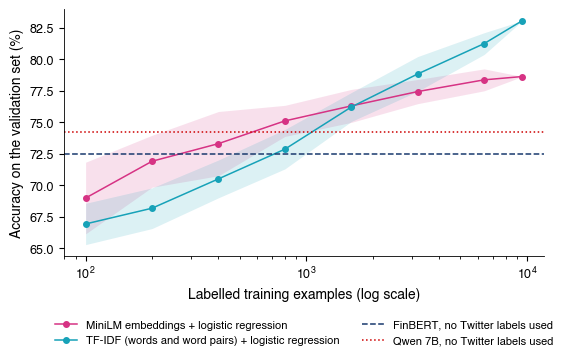

,emb_acc,tfidf_acc,emb_f1,tfidf_f1
100,0.690,0.669,0.433,0.327
200,0.719,0.682,0.539,0.380
400,0.733,0.705,0.586,0.446
800,0.751,0.729,0.630,0.521
1600,0.763,0.762,0.661,0.613
3200,0.774,0.788,0.681,0.675
6400,0.784,0.813,0.695,0.722
9543,0.786,0.831,0.699,0.755


In [13]:
def fig_embeddings(tw):
    fig, ax = plt.subplots(figsize=(5.6, 3.6))
    for l in ('neutral', 'positive', 'negative'):
        q = tw[tw['label'] == l]
        ax.scatter(q['pc1'], q['pc2'], s=5, alpha=0.55, color=LAB_COL[l], label=f'{l} ({len(q):,})', lw=0)
    ax.set_xlabel('First principal component')
    ax.set_ylabel('Second principal component')
    legend_outside_bottom(ax, ncol=3, y=-0.18, markerscale=3)
    save_fig('ch15_embeddings')


def fig_learning_curve():
    lc = load_csv('ch15_learning_curve.csv')
    grp = lc.groupby('n')
    m, s = grp.mean(), grp.std().fillna(0)
    R = RES['texts']['tw']
    fig, ax = plt.subplots(figsize=(6.2, 3.2))
    for k, c, lab in (('emb', Magenta, 'MiniLM embeddings + logistic regression'),
                      ('tfidf', Teal, 'TF-IDF (words and word pairs) + logistic regression')):
        ax.plot(m.index, 100 * m[f'{k}_acc'], 'o-', color=c, label=lab, ms=4)
        ax.fill_between(m.index, 100 * (m[f'{k}_acc'] - 2 * s[f'{k}_acc']), 100 * (m[f'{k}_acc'] + 2 * s[f'{k}_acc']),
                        color=c, alpha=0.15, lw=0)
    for mm, c, ls in (('FinBERT', MainBlue, '--'), ('Qwen 7B', IDAred, ':')):
        ax.axhline(100 * R[mm]['acc'], color=c, ls=ls, lw=1.1, label=f'{mm}, no Twitter labels used')
    ax.set_xscale('log')
    ax.set_xlabel('Labelled training examples (log scale)')
    ax.set_ylabel('Accuracy on the validation set (%)')
    legend_outside_bottom(ax, ncol=2, y=-0.22)
    save_fig('ch15_learning_curve')


fig_embeddings(tw)
fig_learning_curve()
pd.DataFrame(RES['texts']['lc']).T.round(3)

## 5. Look-ahead bias: does the model already know the answer?

- Qwen2.5 is asked, with no context, whether the S&P 500 rose or fell in a given month, and whether Apple rose or fell on a given day.
- AUC before and after the release of the weights (19 September 2024).

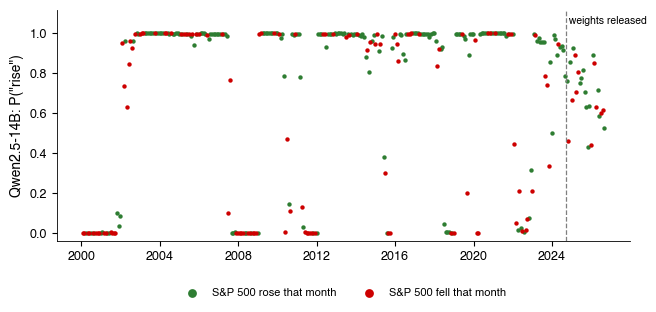

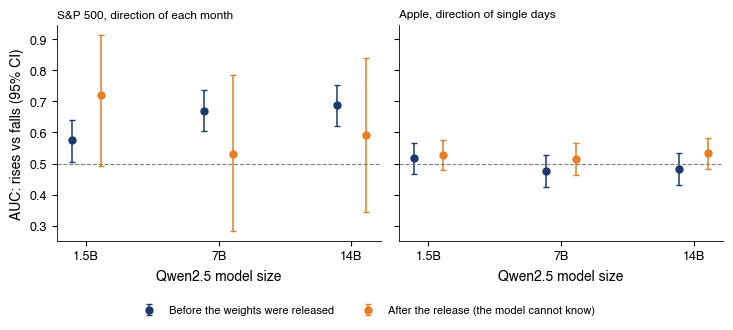

,1.5B,7B,14B
pre,"{'auc': 0.5745556367177989, 'lo': 0.5059686091...","{'auc': 0.6700267835402971, 'lo': 0.6056984737...","{'auc': 0.6872656440224008, 'lo': 0.6221625099..."
post,"{'auc': 0.7192307692307692, 'lo': 0.4924213286...","{'auc': 0.5307692307692308, 'lo': 0.2833333333...","{'auc': 0.5923076923076923, 'lo': 0.3451388888..."


In [14]:
def stats_auc(a, b):
    from scipy.stats import mannwhitneyu
    if len(a) == 0 or len(b) == 0:
        return np.nan
    return mannwhitneyu(a, b).statistic / (len(a) * len(b))


def auc(p, up):
    p, up = np.asarray(p), np.asarray(up, bool)
    return float(stats_auc(p[up], p[~up]))


def boot_auc(p, up, B=2000, seed=0):
    rng = np.random.default_rng(seed)
    p, up = np.asarray(p), np.asarray(up, bool)
    v = []
    for _ in range(B):
        i = rng.integers(0, len(p), len(p))
        if up[i].all() or (~up[i]).all():
            continue
        v.append(stats_auc(p[i][up[i]], p[i][~up[i]]))
    return tuple(np.quantile(v, [0.025, 0.975]))


def eval_memory():
    mm = load_csv('ch15_memory_monthly.csv', index_col=0, parse_dates=True)
    md = load_csv('ch15_memory_daily.csv', index_col=0, parse_dates=True)
    R = {}
    for name, d, cut_pre, cut_post in (('monthly', mm, '2024-08-31', '2024-10-01'),
                                       ('daily', md, '2023-12-31', '2024-10-01')):
        up = d['ret'] > 0
        R[name] = {}
        for s in ('1.5B', '7B', '14B'):
            col = f'qwen{s}'
            r = {}
            for per, sel in (('pre', d.index <= cut_pre), ('post', d.index >= cut_post)):
                p, u = d.loc[sel, col].values, up[sel].values
                lo, hi = boot_auc(p, u)
                ba = 0.5 * (np.mean(p[u] > 0.5) + np.mean(p[~u] <= 0.5))
                r[per] = {'auc': auc(p, u), 'lo': lo, 'hi': hi, 'ba': float(ba), 'n': int(sel.sum()),
                          'n_up': int(u.sum()), 'p_rise': float(np.mean(p > 0.5))}
            R[name][s] = r
    # the best-known months
    pre = mm.loc[:'2024-08-31']
    worst = pre.nsmallest(8, 'ret')
    R['worst'] = {d.strftime('%Y-%m'): {'ret': float(r['ret']), 'p14': float(r['qwen14B'])} for d, r in worst.iterrows()}
    R['range'] = {'m_start': mm.index[0].strftime('%Y-%m'), 'm_end': mm.index[-1].strftime('%Y-%m'),
                  'd_pre_start': md.index[0].strftime('%Y-%m-%d')}
    RES['memory'] = R
    return mm, md


def fig_memory_timeline(mm):
    fig, ax = plt.subplots(figsize=(7.4, 3.0))
    up = mm['ret'] > 0
    ax.scatter(mm.index[up], mm.loc[up, 'qwen14B'], s=10, color=Forest, label='S&P 500 rose that month', lw=0)
    ax.scatter(mm.index[~up], mm.loc[~up, 'qwen14B'], s=10, color=IDAred, label='S&P 500 fell that month', lw=0)
    ax.axvline(pd.Timestamp(QWEN_RELEASE), color=Gray, ls='--', lw=0.9)
    ax.text(pd.Timestamp(QWEN_RELEASE), 1.04, ' weights released', fontsize=7.5, color='black', va='bottom')
    ax.set_ylabel('Qwen2.5-14B: P("rise")')
    ax.set_ylim(-0.04, 1.12)
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    legend_outside_bottom(ax, ncol=2, y=-0.16, markerscale=2)
    save_fig('ch15_memory_timeline')


def fig_memory_auc():
    R = RES['memory']
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0), sharey=True)
    for ax, name, title in zip(axes, ('monthly', 'daily'), ('S&P 500, direction of each month',
                                                             'Apple, direction of single days')):
        x = np.arange(3)
        for k, (per, c, lab) in enumerate((('pre', MainBlue, 'Before the weights were released'),
                                          ('post', Orange, 'After the release (the model cannot know)'))):
            vals = [R[name][s][per] for s in ('1.5B', '7B', '14B')]
            ax.errorbar(x + (k - 0.5) * 0.22, [v['auc'] for v in vals],
                        yerr=[[v['auc'] - v['lo'] for v in vals], [v['hi'] - v['auc'] for v in vals]],
                        fmt='o', color=c, capsize=2, ms=5, label=lab)
        ax.axhline(0.5, color=Gray, ls='--', lw=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(['1.5B', '7B', '14B'])
        ax.set_title(title, fontsize=8.5, loc='left')
        ax.set_xlabel('Qwen2.5 model size')
    axes[0].set_ylabel('AUC: rises vs falls (95% CI)')
    h, l = axes[0].get_legend_handles_labels()
    fig.tight_layout()
    fig_legend_bottom(fig, h, l, ncol=2, y=0.0)
    save_fig('ch15_memory_auc')


mm, md = eval_memory()
fig_memory_timeline(mm)
fig_memory_auc()
pd.DataFrame(RES['memory']['monthly']).round(3)

## 6. From headline sentiment to a trading signal (FNSPID)

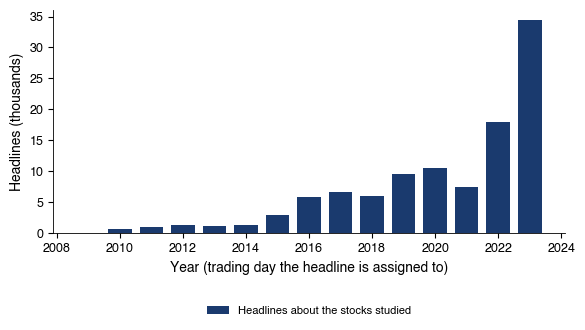

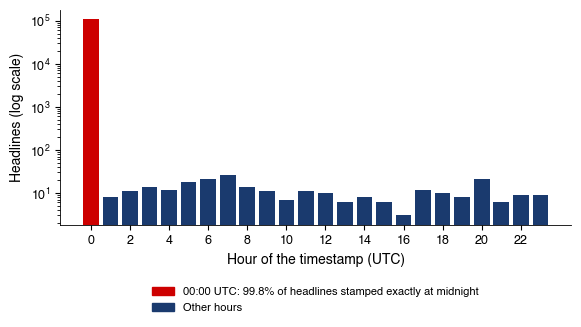

In [15]:
def fig_news_coverage():
    cnt = load_csv('ch15_news_counts.csv', index_col=0)
    tot = cnt.sum(1)
    fig, ax = plt.subplots(figsize=(6.6, 2.9))
    ax.bar(tot.index.astype(int), tot.values / 1e3, color=MainBlue, width=0.75, label='Headlines about the stocks studied')
    ax.set_ylabel('Headlines (thousands)')
    ax.set_xlabel('Year (trading day the headline is assigned to)')
    legend_outside_bottom(ax, ncol=1, y=-0.28)
    save_fig('ch15_news_coverage')


def fig_news_hours():
    h = load_csv('ch15_news_hours.csv', index_col=0)
    fig, ax = plt.subplots(figsize=(6.6, 2.8))
    ax.bar(h.index, h['n'], color=[IDAred if x == 0 else MainBlue for x in h.index], width=0.8)
    ax.set_yscale('log')
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlabel('Hour of the timestamp (UTC)')
    ax.set_ylabel('Headlines (log scale)')
    h1 = [plt.Rectangle((0, 0), 1, 1, color=IDAred), plt.Rectangle((0, 0), 1, 1, color=MainBlue)]
    ax.legend(h1, [f'00:00 UTC: {100 * h["share_midnight"].iloc[0]:.1f}% of headlines stamped exactly at midnight',
                   'Other hours'], loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=1, frameon=False)
    RES.setdefault('news', {})['midnight'] = float(h['share_midnight'].iloc[0])
    save_fig('ch15_news_hours')


fig_news_coverage()
fig_news_hours()

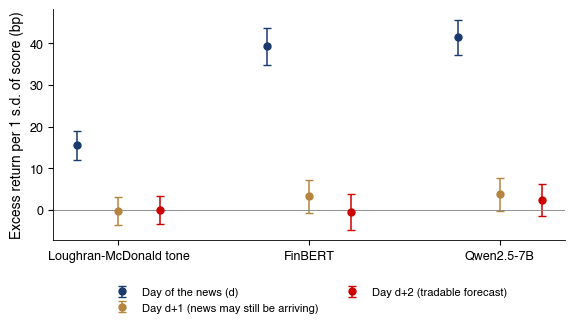

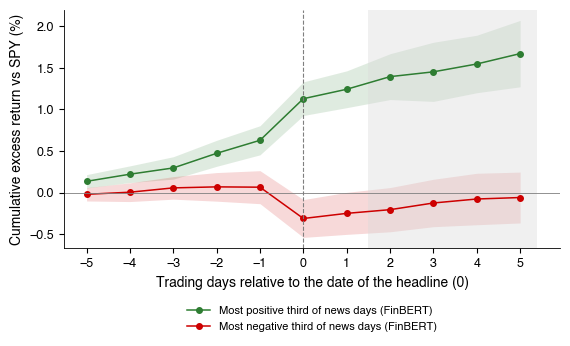

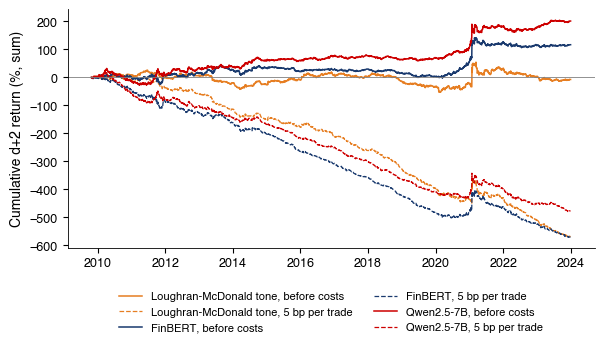

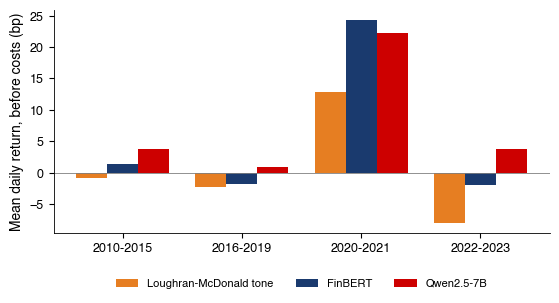

,b,se_ols,se_cl,t_ols,t_cl
lm|r0,0.1547,0.0232,0.0181,6.6570,8.5343
lm|r1,-0.0037,0.0223,0.0171,-0.1635,-0.2135
lm|r2,-0.0003,0.0218,0.0174,-0.0118,-0.0148
finbert|r0,0.3923,0.0231,0.0227,16.9879,17.2712
finbert|r1,0.0318,0.0223,0.0199,1.4262,1.6002
finbert|r2,-0.0054,0.0218,0.0215,-0.2460,-0.2491
qwen|r0,0.4145,0.0231,0.0217,17.9649,19.0684
qwen|r1,0.0369,0.0223,0.0198,1.6547,1.8619
qwen|r2,0.0232,0.0218,0.0194,1.0621,1.1945


In [16]:
def news_panel():
    daily = load_csv('ch15_news_daily.csv', parse_dates=['day']).set_index(['day', 'ticker'])
    syms = sorted(set(TICKERS.values()))
    rets = stock_returns(syms + ['SPY.US'], start='2009-01-01')
    rets.columns = [c.replace('.US', '') for c in rets.columns]
    rets = rets.loc[:'2023-12-31']
    P = daily_panel(daily, rets)
    for c in SCORE_LBL:
        P[f'z_{c}'] = (P[c] - P[c].mean()) / P[c].std()
    return P, rets


def event_groups(x):
    """Event-study groups: the most negative and the most positive tercile of the daily score. If the two
    cut-offs coincide (the LM tone is exactly 0 on almost half of the stock-days), the disjoint groups are
    score < cut-off and score > cut-off, and days equal to the cut-off are excluded."""
    q1, q2 = x.quantile([1 / 3, 2 / 3])
    if q1 >= q2:
        return x < q1, x > q2
    return x <= q1, x >= q2


def eval_news(P, rets):
    cnt = load_csv('ch15_news_counts.csv', index_col=0)
    hl = load_csv('ch15_news_headlines.csv.gz', usecols=['finbert', 'lm', 'lm_hit', 'qwen', 'finbert_lab'])
    R = {'n_headlines': int(cnt.values.sum()), 'n_tickers': int((cnt.sum() > 0).sum()),
         'n_obs': len(P), 'n_days': int(P.index.get_level_values('day').nunique()),
         'first': str(P.index.get_level_values('day').min().date()),
         'last': str(P.index.get_level_values('day').max().date()),
         'per_year': cnt.sum(1).to_dict(), 'per_ticker': cnt.sum().sort_values(ascending=False).to_dict(),
         'mean_n': float(P['n'].mean()), 'lm_hit': float(hl['lm_hit'].mean()),
         'fb_share': (hl['finbert_lab'].value_counts(normalize=True).sort_index()).tolist(),
         'corr': hl[['lm', 'finbert', 'qwen']].corr().round(3).to_dict(),
         'corr_daily': P[['lm', 'finbert', 'qwen']].corr().round(3).to_dict()}
    R['reg'] = {}
    groups = P.index.get_level_values('day')
    for c in SCORE_LBL:
        for y in ('r0', 'r1', 'r2'):
            R['reg'][f'{c}|{y}'] = {k: float(v) for k, v in cluster_ols(P[y].values, P[f'z_{c}'].values,
                                                                           groups).items()}
    # event study: terciles of the FinBERT score
    cols = EVENT_COLS
    R['event'] = {}
    for c in ('finbert', 'qwen', 'lm'):
        neg, pos = event_groups(P[c])
        ev = {}
        for grp, sel in (('neg', neg), ('pos', pos)):
            X = P.loc[sel, cols].groupby(level='day').mean()
            car = X.fillna(0).cumsum(axis=1)
            ev[grp] = {'car': car.mean().tolist(), 'se': (car.std() / np.sqrt(len(car))).tolist(), 'n_days': len(X),
                       'n': int(sel.sum())}
        R['event'][c] = ev
    # the strategy
    days = rets.index[(rets.index >= P.index.get_level_values('day').min())]
    R['strat'] = {}
    for c in SCORE_LBL:
        St = signal_portfolio(P, c, days, cost_bp=5, ret='r2')
        S1 = signal_portfolio(P, c, days, ret='r1')
        m1, t1 = nw_t(S1['gross'])
        mu, t = nw_t(St['gross'])
        lo, hi = block_boot_mean(St['gross'].values)
        mun, tn = nw_t(St['net'])
        active = St['k'] > 0
        R['strat'][c] = {'mean_bp': 1e2 * mu, 't': t, 'lo_bp': 1e2 * lo, 'hi_bp': 1e2 * hi,
                         'sr': sharpe(St['gross']), 'sr_net': sharpe(St['net']), 't_net': tn,
                         'mean_net_bp': 1e2 * mun, 'active': float(active.mean()),
                         'mean_active_bp': 1e2 * St.loc[active, 'gross'].mean(),
                         'breakeven_bp': 1e2 * St.loc[active, 'gross'].mean() / 4,
                         'r1_mean_bp': 1e2 * m1, 'r1_t': t1, 'r1_sr': sharpe(S1['gross']),
                         'years': {}}
        for a, b in PERIODS:
            x = St.loc[a:b, 'gross']
            m_, t_ = nw_t(x)
            R['strat'][c]['years'][f'{a}-{b}'] = {'mean_bp': 1e2 * m_, 't': t_}
        R['strat'][c]['cum'] = St[['gross', 'net']]
    RES['news'] = R
    return P


def fig_contemp_next():
    R = RES['news']['reg']
    fig, ax = plt.subplots(figsize=(6.6, 3.0))
    x = np.arange(len(SCORE_LBL))
    for k, (y, c, lab) in enumerate((('r0', MainBlue, 'Day of the news (d)'),
                                     ('r1', Amber, 'Day d+1 (news may still be arriving)'),
                                     ('r2', IDAred, 'Day d+2 (tradable forecast)'))):
        b = [100 * R[f'{s}|{y}']['b'] for s in SCORE_LBL]
        e = [1.96 * 100 * R[f'{s}|{y}']['se_cl'] for s in SCORE_LBL]
        ax.errorbar(x + (k - 1) * 0.22, b, yerr=e, fmt='o', color=c, capsize=3, ms=5, label=lab)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([SCORE_LBL[s] for s in SCORE_LBL])
    ax.set_ylabel('Excess return per 1 s.d. of score (bp)')
    legend_outside_bottom(ax, ncol=2, y=-0.16)
    save_fig('ch15_contemp_next')


def fig_event_study():
    R = RES['news']['event']['finbert']
    k = np.arange(-5, 6)
    fig, ax = plt.subplots(figsize=(6.4, 3.1))
    for grp, c, lab in (('pos', Forest, 'Most positive third of news days (FinBERT)'),
                        ('neg', IDAred, 'Most negative third of news days (FinBERT)')):
        car, se = np.array(R[grp]['car']), np.array(R[grp]['se'])
        ax.plot(k, car, 'o-', color=c, label=lab, ms=4)
        ax.fill_between(k, car - 1.96 * se, car + 1.96 * se, color=c, alpha=0.15, lw=0)
    ax.axvline(0, color=Gray, ls='--', lw=0.8)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xticks(k)
    ax.axvspan(1.5, 5.4, color=LightGray, alpha=0.4, lw=0)
    ax.set_xlabel('Trading days relative to the date of the headline (0)')
    ax.set_ylabel('Cumulative excess return vs SPY (%)')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch15_event_study')


def fig_strategy():
    R = RES['news']['strat']
    fig, ax = plt.subplots(figsize=(6.8, 3.1))
    for c in SCORE_LBL:
        St = R[c]['cum']
        ax.plot(St.index, St['gross'].cumsum(), color=SCORE_COL[c], lw=1.1, label=f'{SCORE_LBL[c]}, before costs')
        ax.plot(St.index, St['net'].cumsum(), color=SCORE_COL[c], lw=0.9, ls='--', label=f'{SCORE_LBL[c]}, 5 bp per trade')
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_ylabel('Cumulative d+2 return (%, sum)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch15_strategy')


def fig_subperiods():
    R = RES['news']['strat']
    per = list(R['finbert']['years'])
    fig, ax = plt.subplots(figsize=(6.4, 2.9))
    x = np.arange(len(per))
    for k, c in enumerate(SCORE_LBL):
        ax.bar(x + (k - 1) * 0.26, [R[c]['years'][p]['mean_bp'] for p in per], 0.26, color=SCORE_COL[c],
               label=SCORE_LBL[c])
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(per)
    ax.set_ylabel('Mean daily return, before costs (bp)')
    legend_outside_bottom(ax, ncol=3, y=-0.16)
    save_fig('ch15_subperiods')


P, rets = news_panel()
eval_news(P, rets)
fig_contemp_next()
fig_event_study()
fig_strategy()
fig_subperiods()
pd.DataFrame(RES['news']['reg']).T[['b', 'se_ols', 'se_cl', 't_ols', 't_cl']].round(4)

In [17]:
pd.DataFrame({c: {k: v for k, v in RES['news']['strat'][c].items() if k not in ('years', 'cum')} for c in SCORE_LBL}).round(3)

,lm,finbert,qwen
mean_bp,-0.208,3.270,5.639
t,-0.071,1.273,2.263
lo_bp,-5.313,-1.505,0.945
hi_bp,6.329,8.932,10.605
sr,-0.018,0.362,0.625
sr_net,-1.399,-1.769,-1.481
t_net,-5.399,-6.215,-5.369
mean_net_bp,-15.920,-15.979,-13.363
active,0.786,0.962,0.950
mean_active_bp,-0.265,3.398,5.935


## 7. Sentiment scores are estimates: measurement error and valid inference

- Attenuation (Aigner, 1973), a one-factor model and instruments with two scores, prediction-powered inference (Angelopoulos et al., 2023).
- Calibration of LLM probabilities, wild cluster bootstrap with 16 stocks, Holm, event-study differences, the specification curve, the DeLong test.

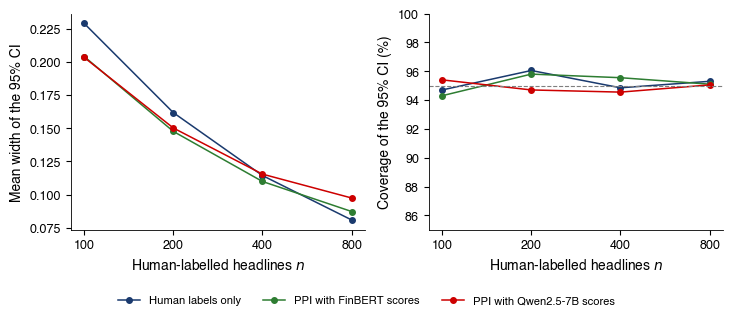

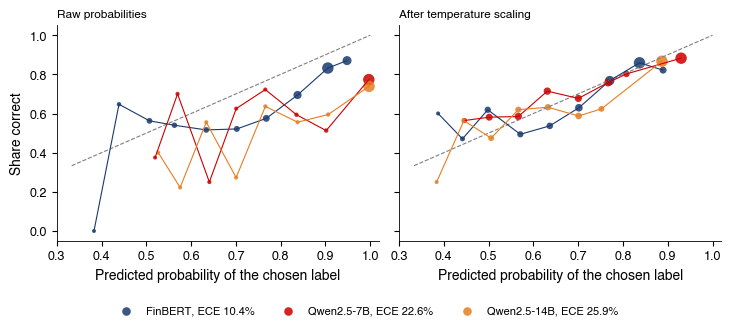

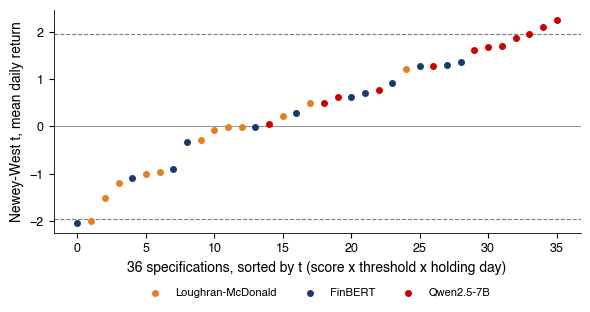

{
 "atten": {
  "rho": {
   "lm": 0.28903644442357884,
   "finbert": 0.5814097093374065,
   "qwen": 0.710594883398976
  },
  "lam_label": {
   "lm": 0.32380644497670974,
   "finbert": 0.4827426461331875,
   "qwen": 0.5733729552479653
  },
  "aigner_neg": {
   "lm": {
    "pi": 0.14530988274706869,
    "p": 0.19430485762144054,
    "a0": 0.14306712395884372,
    "a1": 0.5043227665706052,
    "lam": 0.2797333142160729,
    "lam_direct": 0.2797333142160728
   },
   "finbert": {
    "pi": 0.14530988274706869,
    "p": 0.22403685092127304,
    "a0": 0.13277804997550222,
    "a1": 0.23919308357348704,
    "lam": 0.4486657151071009,
    "lam_direct": 0.4486657151071012
   },
   "qwen": {
    "pi": 0.14530988274706869,
    "p": 0.20770519262981574,
    "a0": 0.09407153356197942,
    "a1": 0.1239193083573487,
    "lam": 0.590175953079179,
    "lam_direct": 0.5901759530791808
   }
  }
 },
 "ppi": {
  "theta": 0.05360134003350084,
  "N": 2388,
  "naive": {
   "finbert": -0.014069440954773858,
   

In [18]:
def net(d, tag):
    return d[f'{tag}_positive'].values - d[f'{tag}_negative'].values


def label_num(d, tag):
    P = d[[f'{tag}_{l}' for l in LABELS]].values
    return P.argmax(1) - 1


def attenuation():
    tw = load_csv('ch15_twitter_scores.csv')
    s = tw['label'].map(SIGN).values.astype(float)
    sc = {'lm': tw['LM_tone'].values, 'finbert': net(tw, 'finbert'), 'qwen': net(tw, 'qwen7B')}
    lab = {'lm': tone_label(tw['LM_tone'].values), 'finbert': label_num(tw, 'finbert'), 'qwen': label_num(tw, 'qwen7B')}
    lab['lm'] = pd.Series(lab['lm']).map(SIGN).values
    out = {'rho': {}, 'lam_label': {}, 'aigner_neg': {}}
    for c in sc:
        out['rho'][c] = float(np.corrcoef(s, sc[c])[0, 1])
        L = lab[c].astype(float)
        out['lam_label'][c] = float(np.cov(s, L)[0, 1] / np.var(L, ddof=1))
        # Aigner (1973): binary "negative news" variable, misclassification
        t, h = (s == -1), (L == -1)
        pi, p = t.mean(), h.mean()
        a1 = np.mean(~h[t])          # P(predicted non-negative | truly negative)
        a0 = np.mean(h[~t])          # P(predicted negative | truly non-negative)
        lam = pi * (1 - pi) * (1 - a0 - a1) / (p * (1 - p))
        out['aigner_neg'][c] = {'pi': float(pi), 'p': float(p), 'a0': float(a0), 'a1': float(a1), 'lam': float(lam),
                                'lam_direct': float(np.cov(t, h)[0, 1] / np.var(h, ddof=1))}
    VI['atten'] = out
    return out


def factor_iv(P):
    """One-factor model for the three daily scores and IV with one score as the instrument for another."""
    Z = {c: P[f'z_{c}'].values for c in ('lm', 'finbert', 'qwen')}
    C = np.corrcoef(np.vstack([Z['lm'], Z['finbert'], Z['qwen']]))
    r = {('lm', 'finbert'): C[0, 1], ('lm', 'qwen'): C[0, 2], ('finbert', 'qwen'): C[1, 2]}
    rr = lambda a, b: r[(a, b)] if (a, b) in r else r[(b, a)]    # noqa: E731
    lam = {}
    for c in Z:
        o = [x for x in Z if x != c]
        lam[c] = float(np.sqrt(rr(c, o[0]) * rr(c, o[1]) / rr(o[0], o[1])))
    days = P.index.get_level_values('day')
    codes, uniq = pd.factorize(days)
    y = P['r0'].values
    rng = np.random.default_rng(15)
    out = {'lam_factor': lam, 'corr': {f'{a}|{b}': float(v) for (a, b), v in r.items()}, 'iv': {}}
    B = 999
    Gs = len(uniq)
    # sums by day for the cluster (day) bootstrap
    def sums(v):
        return np.bincount(codes, weights=v, minlength=Gs)
    raw = {'n': np.ones_like(y), 'y': y}
    raw.update({f'z{c}': Z[c] for c in Z})
    raw.update({f'yz{c}': y * Z[c] for c in Z})
    raw.update({f'{a}{b}': Z[a] * Z[b] for a in Z for b in Z})
    base = {k: sums(v) for k, v in raw.items()}

    def iv_from(S, x, zi):
        n = S['n']
        mx, mz, my = S[f'z{x}'] / n, S[f'z{zi}'] / n, S['y'] / n
        return (S[f'yz{zi}'] / n - my * mz) / (S[f'{x}{zi}'] / n - mx * mz)
    pairs = [('qwen', 'finbert'), ('qwen', 'lm'), ('finbert', 'qwen'), ('finbert', 'lm')]
    tot = {k: v.sum() for k, v in base.items()}
    est = {f'{x}|{zi}': float(iv_from(tot, x, zi)) for x, zi in pairs}
    boots = {k: [] for k in est}
    for _ in range(B):
        w = np.bincount(rng.integers(0, Gs, Gs), minlength=Gs)
        Sb = {k: (v * w).sum() for k, v in base.items()}
        for x, zi in pairs:
            boots[f'{x}|{zi}'].append(iv_from(Sb, x, zi))
    for k in est:
        v = np.array(boots[k])
        out['iv'][k] = {'b_bp': 100 * est[k], 'se_bp': 100 * float(v.std(ddof=1)),
                        'lo_bp': 100 * float(np.quantile(v, 0.025)), 'hi_bp': 100 * float(np.quantile(v, 0.975))}
    for x in ('qwen', 'finbert'):
        o = 'finbert' if x == 'qwen' else 'qwen'
        d = np.array(boots[f'{x}|{o}']) - np.array(boots[f'{x}|lm'])
        dd = est[f'{x}|{o}'] - est[f'{x}|lm']
        out['iv'][f'diff_{x}'] = {'d_bp': 100 * dd, 'se_bp': 100 * float(d.std(ddof=1)),
                                  'z': float(dd / d.std(ddof=1))}
    VI['factor'] = out
    return out


def ppi_sim(ns=(100, 200, 400, 800), R=2000, seed=15):
    """PPI (Angelopoulos et al., 2023): labelled sample (n) and unlabelled sample (N - n) INDEPENDENT, predictor
    f fixed (trained on other data). The simulation treats the N validation headlines as the population: in each replication
    both samples are drawn independently, with replacement, so the variance Var(f)/(N - n) + Var(f - Y)/n is exact,
    and theta (the mean of the N labels) is the population mean."""
    tw = load_csv('ch15_twitter_scores.csv')
    y = tw['label'].map(SIGN).values.astype(float)
    theta = y.mean()
    F = {'finbert': net(tw, 'finbert'), 'qwen': net(tw, 'qwen7B')}
    N = len(y)
    rng = np.random.default_rng(seed)
    z = stats.norm.ppf(0.975)
    out = {'theta': float(theta), 'N': N, 'naive': {c: float(F[c].mean()) for c in F}, 'by_n': {}}
    for n in ns:
        res = {'classical': [], 'ppi_finbert': [], 'ppi_qwen': []}
        for _ in range(R):
            L, U = rng.integers(0, N, n), rng.integers(0, N, N - n)
            m, se = y[L].mean(), y[L].std(ddof=1) / np.sqrt(n)
            res['classical'].append((m, se))
            for c in F:
                f = F[c]
                rect = f[L] - y[L]
                est = f[U].mean() - rect.mean()
                se_p = np.sqrt(f[U].var(ddof=1) / len(U) + rect.var(ddof=1) / n)
                res[f'ppi_{c}'].append((est, se_p))
        r = {}
        for k, v in res.items():
            v = np.array(v)
            r[k] = {'cover': float(np.mean(np.abs(v[:, 0] - theta) <= z * v[:, 1])), 'width': float(np.mean(2 * z * v[:, 1])),
                    'bias': float(v[:, 0].mean() - theta)}
        out['by_n'][str(n)] = r
    # a concrete example with n = 200 (a random split of the headlines: n labelled, the rest unlabelled)
    idx = np.random.default_rng(1).permutation(N)
    L, U = idx[:200], idx[200:]
    ex = {'classical': (y[L].mean(), y[L].std(ddof=1) / np.sqrt(200))}
    for c in F:
        rect = F[c][L] - y[L]
        ex[c] = (F[c][U].mean() - rect.mean(), np.sqrt(F[c][U].var(ddof=1) / len(U) + rect.var(ddof=1) / 200),
                 rect.mean())
    out['example'] = {k: [float(x) for x in v] for k, v in ex.items()}
    # variance of the rectifier vs variance of the labels: the efficiency gain
    out['var_ratio'] = {c: float((F[c] - y).var() / y.var()) for c in F}
    VI['ppi'] = out
    return out


def fig_ppi():
    R = VI['ppi']
    ns = [int(n) for n in R['by_n']]
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 2.9))
    lab = {'classical': 'Human labels only', 'ppi_finbert': 'PPI with FinBERT scores',
           'ppi_qwen': 'PPI with Qwen2.5-7B scores'}
    col = {'classical': MainBlue, 'ppi_finbert': Forest, 'ppi_qwen': IDAred}
    for k in lab:
        axes[0].plot(ns, [R['by_n'][str(n)][k]['width'] for n in ns], 'o-', color=col[k], label=lab[k], ms=4)
        axes[1].plot(ns, [100 * R['by_n'][str(n)][k]['cover'] for n in ns], 'o-', color=col[k], ms=4)
    axes[1].axhline(95, color=Gray, ls='--', lw=0.8)
    axes[0].set_xscale('log')
    axes[1].set_xscale('log')
    from matplotlib.ticker import NullFormatter, NullLocator
    for ax in axes:
        ax.set_xticks(ns)
        ax.set_xticklabels([str(n) for n in ns])
        ax.xaxis.set_minor_locator(NullLocator())
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.set_xlabel('Human-labelled headlines $n$')
    axes[0].set_ylabel('Mean width of the 95% CI')
    axes[1].set_ylabel('Coverage of the 95% CI (%)')
    axes[1].set_ylim(85, 100)
    h, l = axes[0].get_legend_handles_labels()
    fig.tight_layout()
    fig_legend_bottom(fig, h, l, ncol=3, y=0.0)
    save_fig('ch15_ppi')


def calib_stats(P, y, bins=10):
    conf = P.max(1)
    pred = P.argmax(1)
    hit = (pred == y).astype(float)
    edges = np.linspace(1 / 3, 1, bins + 1)
    k = np.clip(np.digitize(conf, edges[1:-1]), 0, bins - 1)
    ece = sum(np.abs(hit[k == b].mean() - conf[k == b].mean()) * np.mean(k == b) for b in range(bins) if np.any(k == b))
    Y = np.eye(3)[y]
    brier = float(np.mean(np.sum((P - Y) ** 2, 1)))
    ll = float(-np.mean(np.log(np.clip(P[np.arange(len(y)), y], 1e-12, 1))))
    rel = [(float(conf[k == b].mean()), float(hit[k == b].mean()), int(np.sum(k == b))) for b in range(bins) if np.any(k == b)]
    return {'ece': float(ece), 'brier': brier, 'logloss': ll, 'acc': float(hit.mean()), 'rel': rel}


def temp_scale(P, T):
    L = np.log(np.clip(P, 1e-12, 1)) / T
    L -= L.max(1, keepdims=True)
    E = np.exp(L)
    return E / E.sum(1, keepdims=True)


def calibration(seed=15):
    tw = load_csv('ch15_twitter_scores.csv')
    y = tw['label'].map({'negative': 0, 'neutral': 1, 'positive': 2}).values
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(y))
    A, B = idx[:len(y) // 2], idx[len(y) // 2:]
    out = {}
    for name, tag in (('finbert', 'finbert'), ('qwen7', 'qwen7B'), ('qwen14', 'qwen14B'),
                      ('qwen7_P2', 'qwen7B_P2'), ('qwen7_P3', 'qwen7B_P3')):
        P = tw[[f'{tag}_{l}' for l in LABELS]].values.astype(float)
        P = P / P.sum(1, keepdims=True)
        nll = lambda T: -np.mean(np.log(np.clip(temp_scale(P[A], T)[np.arange(len(A)), y[A]], 1e-12, 1)))  # noqa: E731
        T = float(minimize_scalar(nll, bounds=(0.05, 50), method='bounded').x)
        out[name] = {'raw': calib_stats(P[B], y[B]), 'T': T, 'scaled': calib_stats(temp_scale(P[B], T), y[B]),
                     'all': calib_stats(P, y)}
    VI['calib'] = out
    return out


def fig_calibration():
    R = VI['calib']
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0), sharey=True)
    for ax, key, title in ((axes[0], 'raw', 'Raw probabilities'), (axes[1], 'scaled', 'After temperature scaling')):
        ax.plot([1 / 3, 1], [1 / 3, 1], color=Gray, ls='--', lw=0.8)
        for m, c, lab in (('finbert', MainBlue, 'FinBERT'), ('qwen7', IDAred, 'Qwen2.5-7B'),
                          ('qwen14', Orange, 'Qwen2.5-14B')):
            rel = np.array(R[m][key]['rel'])
            ax.scatter(rel[:, 0], rel[:, 1], s=8 + 60 * rel[:, 2] / rel[:, 2].max(), color=c, alpha=0.85,
                       label=f"{lab}, ECE {100 * R[m][key]['ece']:.1f}%" if key == 'raw' else lab, lw=0)
            ax.plot(rel[:, 0], rel[:, 1], color=c, lw=0.8)
        ax.set_title(title, fontsize=8.5, loc='left')
        ax.set_xlabel('Predicted probability of the chosen label')
        ax.set_xlim(0.3, 1.02)
    axes[0].set_ylabel('Share correct')
    h, l = axes[0].get_legend_handles_labels()
    fig.tight_layout()
    fig_legend_bottom(fig, h, l, ncol=3, y=0.0)
    save_fig('ch15_calibration')


def wcr_boot(y, x, cl, B=9999, seed=15):
    """Restricted wild cluster bootstrap (b = 0), Rademacher weights, t with CR1 clustered SE."""
    y, x = np.asarray(y, float), np.asarray(x, float)
    codes, uniq = pd.factorize(np.asarray(cl))
    G, n = len(uniq), len(y)
    xd = x - x.mean()
    Sxx = xd @ xd
    cr1 = G / (G - 1) * (n - 1) / (n - 2)

    def tstat(yy):
        b = xd @ yy / Sxx
        e = yy - yy.mean() - b * xd
        s = np.bincount(codes, weights=xd * e, minlength=G)
        return b / np.sqrt(cr1 * (s @ s) / Sxx ** 2)
    t0 = tstat(y)
    et = y - y.mean()                      # residuals of the restricted model
    Ag = np.bincount(codes, weights=xd * et, minlength=G)
    Bg = np.bincount(codes, weights=xd * xd, minlength=G)
    Cg = np.bincount(codes, weights=et, minlength=G)
    Dg = np.bincount(codes, weights=xd, minlength=G)
    rng = np.random.default_rng(seed)
    W = rng.choice([-1.0, 1.0], size=(B, G))
    b = W @ Ag / Sxx
    dm = W @ Cg / n                        # deviation of the mean of y*
    S = W * Ag[None, :] - dm[:, None] * Dg[None, :] - b[:, None] * Bg[None, :]
    t = b / np.sqrt(cr1 * np.sum(S ** 2, 1) / Sxx ** 2)
    return float(t0), float(np.mean(np.abs(t) >= abs(t0)))


def twoway_se(y, x, c1, c2):
    """Two-way clustered SE (Cameron, Gelbach & Miller, 2011): V1 + V2 - V12."""
    y, x = np.asarray(y, float), np.asarray(x, float)
    xd = x - x.mean()
    Sxx = xd @ xd
    b = xd @ y / Sxx
    e = y - y.mean() - b * xd
    u = xd * e

    def V(cl):
        codes = pd.factorize(np.asarray(cl))[0]
        s = np.bincount(codes, weights=u)
        G = len(s)
        return G / (G - 1) * (s @ s) / Sxx ** 2
    inter = pd.Series(list(zip(c1, c2))).astype(str).values
    v = V(c1) + V(c2) - V(inter)
    return float(b), float(np.sqrt(max(v, 0)))


def holm(p):
    p = np.asarray(p, float)
    m = len(p)
    o = np.argsort(p)
    adj = np.empty(m)
    run = 0
    for k, i in enumerate(o):
        run = max(run, (m - k) * p[i])
        adj[i] = min(1.0, run)
    return adj


def panel_inference(P, strat=None):
    days = P.index.get_level_values('day')
    tic = P.index.get_level_values('ticker')
    rows = {}
    for c in ('lm', 'finbert', 'qwen'):
        for h in ('r0', 'r1', 'r2'):
            y, x = P[h].values, P[f'z_{c}'].values
            t_tic, p_wcr = wcr_boot(y, x, tic)
            b, se2 = twoway_se(y, x, days, tic)
            rows[f'{c}|{h}'] = {'b_bp': 100 * b, 't_tic': t_tic, 'p_t15': float(2 * stats.t.sf(abs(t_tic), 15)),
                                'p_wcr': p_wcr, 't_2way': b / se2, 'p_2way': float(2 * stats.t.sf(abs(b / se2), 15))}
    keys = list(rows)
    adj = holm([rows[k]['p_wcr'] for k in keys])
    for k, a in zip(keys, adj):
        rows[k]['p_wcr_holm'] = float(a)
    # the d+2 strategies: Newey-West t, Normal p-value, Holm over 3 scores
    if strat is None:
        with open(os.path.join(HERE, 'ch15_results.json')) as f:
            strat = json.load(f)['news']['strat']
    st = strat
    ps = {c: float(2 * stats.norm.sf(abs(st[c]['t']))) for c in ('lm', 'finbert', 'qwen')}
    ha = holm(list(ps.values()))
    VI['panel'] = {'reg': rows, 'strat_p': ps, 'strat_holm': dict(zip(ps, map(float, ha)))}
    return VI['panel']


def event_inference(P, rets, col='finbert'):
    neg, pos = event_groups(P[col])
    sub = P[neg | pos].copy()
    sub['pos'] = pos[neg | pos].astype(float)
    sub['post'] = sub[['r2', 'rp3', 'rp4', 'rp5']].sum(1, min_count=4)
    sub['pre'] = sub[['rm5', 'rm4', 'rm3', 'rm2', 'rm1']].sum(1, min_count=5)
    out = {}
    for w in ('pre', 'r0', 'r1', 'post'):
        s = sub.dropna(subset=[w])
        r = cluster_ols(s[w].values, s['pos'].values, s.index.get_level_values('day'))
        out[w] = {'d': float(r['b']), 'lo': float(r['b'] - 1.96 * r['se_cl']), 'hi': float(r['b'] + 1.96 * r['se_cl']),
                  't': float(r['t_cl'])}
    # BMP: CAR standardised by the standard deviation of the excess return over the 250 days ending at -6
    ex = rets.drop(columns='SPY').sub(rets['SPY'], axis=0)
    sd = ex.rolling(250, min_periods=120).std().shift(6)
    sds = sd.stack()
    sds.index.names = ['day', 'ticker']
    sub = sub.join(sds.rename('sig'), how='left').dropna(subset=['sig', 'post'])
    sub['scar'] = sub['post'] / (sub['sig'] * np.sqrt(4))
    for grp, sel in (('pos', sub['pos'] == 1), ('neg', sub['pos'] == 0)):
        v = sub.loc[sel, 'scar'].values
        out[f'bmp_{grp}'] = {'mean_scar': float(v.mean()), 'z': float(v.mean() * np.sqrt(len(v)) / v.std(ddof=1)),
                             'n': int(len(v))}
    VI['event'] = out
    return out


def nw_t_mat(X, L):
    n = X.shape[1]
    mu = X.mean(1)
    U = X - mu[:, None]
    v = np.sum(U * U, 1) / n
    for l in range(1, L + 1):
        v += 2 * (1 - l / (L + 1)) * np.sum(U[:, l:] * U[:, :-l], 1) / n
    return mu / np.sqrt(v / n)


def portfolio(P, col, days, band, ret, lag):
    q = P[P[col].abs() > band]
    pos_day = pd.DatetimeIndex(days)
    idx = pos_day.get_indexer(q.index.get_level_values('day'))
    ok = (idx >= 0) & (idx + lag < len(pos_day))
    q = q[ok]
    x = pd.Series(np.sign(q[col].values) * q[ret].values, index=pos_day[idx[ok] + lag])
    return x.groupby(level=0).mean().reindex(pos_day).fillna(0.0)


def spec_curve(P, rets, B=2000, seed=15, block=10):
    """Joint null: Rademacher weights constant over blocks of `block` consecutive signal days (dependent wild
    bootstrap, Shao, 2010), the same for all specifications. Assumptions: under the null, the signed returns of each
    block are symmetric around 0 and the blocks are roughly independent; the dependence between
    specifications and the serial dependence within a block are preserved."""
    days = rets.index[rets.index >= P.index.get_level_values('day').min()]
    series = []
    meta = []
    for c in SCORES:
        for b in BANDS:
            for ret, lag in HOLD.items():
                x = portfolio(P.dropna(subset=[ret]), c, days, b, ret, lag)
                # indexed by the signal day (return day minus lag): the same sign flip for all
                s = pd.Series(x.values, index=pd.DatetimeIndex(days)).shift(-lag).reindex(days).fillna(0.0)
                series.append(s.values)
                meta.append({'score': c, 'band': b, 'day': lag})
    X = np.vstack(series)
    n = X.shape[1]
    L = int(np.floor(4 * (n / 100) ** (2 / 9)))
    t_obs = nw_t_mat(X, L)
    rng = np.random.default_rng(seed)
    cnt, med = [], []
    for _ in range(B):
        w = np.repeat(rng.choice([-1.0, 1.0], size=int(np.ceil(n / block))), block)[:n]
        tb = nw_t_mat(X * w[None, :], L)
        cnt.append(np.sum(tb > 1.96))
        med.append(np.median(tb))
    cnt, med = np.array(cnt), np.array(med)
    k_obs = int(np.sum(t_obs > 1.96))
    out = {'t': t_obs.tolist(), 'meta': meta, 'n_pos_sig': k_obs, 'median_t': float(np.median(t_obs)),
           'p_count': float(np.mean(cnt >= k_obs)), 'p_median': float(np.mean(med >= np.median(t_obs))),
           'null_q95_count': float(np.quantile(cnt, 0.95)), 'n_neg_sig': int(np.sum(t_obs < -1.96)), 'B': B,
           'block': block}
    VI['spec'] = out
    return out


def fig_spec_curve():
    R = VI['spec']
    t = np.array(R['t'])
    meta = R['meta']
    o = np.argsort(t)
    col = {'lm': Orange, 'finbert': MainBlue, 'qwen': IDAred}
    lab = {'lm': 'Loughran-McDonald', 'finbert': 'FinBERT', 'qwen': 'Qwen2.5-7B'}
    fig, ax = plt.subplots(figsize=(6.8, 2.9))
    for c in col:
        k = [j for j, i in enumerate(o) if meta[i]['score'] == c]
        ax.scatter(k, t[o][k], color=col[c], s=16, label=lab[c], zorder=3)
    ax.axhline(1.96, color=Gray, ls='--', lw=0.8)
    ax.axhline(-1.96, color=Gray, ls='--', lw=0.8)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xlabel('36 specifications, sorted by t (score x threshold x holding day)')
    ax.set_ylabel('Newey-West t, mean daily return')
    legend_outside_bottom(ax, ncol=3, y=-0.2)
    save_fig('ch15_spec_curve')


def delong_var(p, up):
    p, up = np.asarray(p, float), np.asarray(up, bool)
    X, Y = p[up], p[~up]
    psi = (X[:, None] > Y[None, :]).astype(float) + 0.5 * (X[:, None] == Y[None, :])
    V10, V01 = psi.mean(1), psi.mean(0)
    a = psi.mean()
    return float(a), float(V10.var(ddof=1) / len(X) + V01.var(ddof=1) / len(Y))


def auc_test():
    mm = load_csv('ch15_memory_monthly.csv', index_col=0, parse_dates=True)
    out = {}
    z80 = stats.norm.ppf(0.975) + stats.norm.ppf(0.80)
    for s in ('7B', '14B'):
        pre = mm.loc[:'2024-08-31']
        post = mm.loc['2024-10-01':]
        a1, v1 = delong_var(pre[f'qwen{s}'], pre['ret'] > 0)
        a2, v2 = delong_var(post[f'qwen{s}'], post['ret'] > 0)
        m, n = int((post['ret'] > 0).sum()), int((post['ret'] <= 0).sum())
        v0 = (m + n + 1) / (12 * m * n)       # variance of the AUC when AUC = 0.5 (Hanley & McNeil)
        z = (a1 - a2) / np.sqrt(v1 + v2)
        out[s] = {'auc_pre': a1, 'auc_post': a2, 'se_pre': np.sqrt(v1), 'se_post': np.sqrt(v2), 'z': float(z),
                  'p': float(2 * stats.norm.sf(abs(z))), 'mde': float(z80 * np.sqrt(v1 + v0)),
                  'se0_post': float(np.sqrt(v0)), 'n_up': m, 'n_down': n}
        # months needed after release to detect the fall to 0.5 with 80% power (same share of up months)
        share = m / (m + n)
        need = None
        for T in range(20, 2000):
            mu, nd = max(1, round(share * T)), max(1, T - round(share * T))
            if z80 * np.sqrt(v1 + (mu + nd + 1) / (12 * mu * nd)) <= a1 - 0.5:
                need = T
                break
        out[s]['months_needed'] = need
    VI['auc'] = out
    return out


def leakage_did(B=2000, seed=15):
    pb = load_csv('ch15_phrasebank_scores.csv')
    tw = load_csv('ch15_twitter_scores.csv')
    hit = {}
    for name, d in (('pb', pb), ('tw', tw)):
        pr = predictions(d)
        hit[name] = {m: (pr[m] == d['label'].values).astype(float) for m in ('FinBERT', 'Qwen 7B')}
    did = lambda a, b: (a['FinBERT'].mean() - b['FinBERT'].mean()) - (a['Qwen 7B'].mean() - b['Qwen 7B'].mean())  # noqa
    est = did(hit['pb'], hit['tw'])
    rng = np.random.default_rng(seed)
    v = []
    for _ in range(B):
        i = rng.integers(0, len(pb), len(pb))
        j = rng.integers(0, len(tw), len(tw))
        v.append(did({k: x[i] for k, x in hit['pb'].items()}, {k: x[j] for k, x in hit['tw'].items()}))
    VI['did'] = {'did': float(est), 'lo': float(np.quantile(v, 0.025)), 'hi': float(np.quantile(v, 0.975)),
                 'drop_fb': float(hit['pb']['FinBERT'].mean() - hit['tw']['FinBERT'].mean()),
                 'drop_q7': float(hit['pb']['Qwen 7B'].mean() - hit['tw']['Qwen 7B'].mean())}
    return VI['did']


def timing():
    """Time per headline: one pass for each prompt; median of the three prompts."""
    t = load_csv('ch15_llm_time.csv', index_col=0)['sec_per_text']
    out = {}
    for s in ('0.5B', '1.5B', '3B', '7B', '14B'):
        v = t[[k for k in t.index if k.startswith(f'time_qwen{s}')]].values
        out[s] = {'median': float(np.median(v)), 'min': float(v.min()), 'max': float(v.max()), 'k': int(len(v))}
    VI['time'] = out
    return out


from scipy.optimize import minimize_scalar
VI = {}
SIGN = {'negative': -1, 'neutral': 0, 'positive': 1}
SCORES, BANDS, HOLD = ('lm', 'finbert', 'qwen'), (0.0, 0.25, 0.5), {'r2': 2, 'rp3': 3, 'rp4': 4, 'rp5': 5}
attenuation()
ppi_sim()
fig_ppi()
calibration()
fig_calibration()
leakage_did()
auc_test()
timing()
factor_iv(P)
panel_inference(P, RES['news']['strat'])
event_inference(P, rets)
spec_curve(P, rets)
fig_spec_curve()
print(json.dumps(jsonable({k: v for k, v in VI.items() if k not in ('spec', 'calib')}), indent=1, default=float))